# Анализ датасета YOUTUBE-канала блогера MrBeast

# План проекта: 
    
**1. Постановка задачи**

1.1. Цель исследования

1.2. Бизнес-контекст

1.3. Ключевые вопросы исследования

**2. Первичное знакомство с данными**

2.1. Библиотеки и инструменты 

2.2. Первичное знакомство с датасетом

**3. Предварительный отбор признаков**

**4. Проверка и подготовка данных**

4.1. Структура данных

4.1. Пропуски

4.2. Дубликаты

4.3. Типы данных

4.4. Корректность значений

4.4.1. Числовые признаки и диапазоны значений

4.4.3. Признаки времени публикации

4.4.4. Текстовые и категориальные признаки

4.4.5. Индентификаторы

4.4. Логические взаимосвязи

4.5. Проверка аномальных и экстремальных значений

4.6. Создание производных признаков

4.7. Заключение по проверкам и подготовке данных

4.8. Итоговый дадасет


**5. План аналитического исследования**

5.1.  Основная метрика и направления анализа

5.2. Формирование исследовательских вопросов

5.3. Формирование направлений анализа

5.4. Выбор методов анализа


**6. Исследовательский анализ данных (EDA)**

   6.1. Распределение основной метрики Views
   

   6.2. Views и характеристики контента
   
   6.3. Views и время публикации
   
   6.4. Views, CTR, удержание
   
   6.5. Views и вовлечённость
   
   6.6. Views и рост аудитории
   
   6.7. Анализ взаимосвязей между показателями
   
   6.8. Основные результаты и закономерности EDA
   
**7. Формирование гипотез**

**8. Статистическая проверка гипотез**

**9. Итоговые выводы**

**10. Продуктовые рекомендации**

**11. Ограничения исследования**

# 1. Постановка задачи
# 1.1. Цели исследования

Цель 1. Понять, какие характеристики видео связаны с количеством просмотров

Цель 2. Понять, как характеристики публикации связаны с результативностью

Цель 3. Понять связь результативности видео с вовлечённостью и ростом аудитории

# 1.2. Бизнес-контекст
YouTube-канал в данном проекте рассматривается как медиапродукт, основным продуктом которого является видеоконтент. Для автора YouTube-канала важно не только получать просмотры, но и удерживать аудиторию, стимулировать взаимодействие и привлекать новых подписчиков. Поэтому анализ направлен на выявление факторов, связанных с этими показателями.

# 1.3. Ключевые вопросы исследования
1. Какие характеристики видео связаны с количеством просмотров?

2. Как время публикации связано с результативностью видео?

3. Связаны ли просмотры и вовлечённость с приростом подписчиков?

4. Связан ли прирост подписчиков с количеством просмотров?

# 2. Первичное знакомство с данными

**2.1. Библиотеки и инструменты**

In [1]:
import sys
!{sys.executable} -m pip install statsmodels

In [2]:
import  sys 
!{sys.executable} -m pip install matplotlib.patheffects

ERROR: Could not find a version that satisfies the requirement matplotlib.patheffects (from versions: none)
ERROR: No matching distribution found for matplotlib.patheffects


In [55]:
# для работы с таблицей
import pandas as pd
print(pd.__version__)
# для мат операций
import numpy as np
# для построения графиков.
import matplotlib.pyplot as plt
# для красивых графиков 
import seaborn as sns
import statsmodels as sts
# для проверки гипотез
import scipy.stats as stats
# Для оформления графиков
plt.style.use("ggplot")
sns.set_theme()
# для тестов 
import matplotlib.patheffects as pe
from scipy.stats import spearmanr, pearsonr

3.0.5


In [3]:
import sys
!{sys.executable} -m pip install --upgrade pip

**2.2. Загружаем датасет, первично знакомимся с датасетом**

 **Посмотрим первые 5 строк:**


In [7]:
df = pd.read_csv(r'C:/Users/user/Yandex.Disk/рабочее/projects/mrbeast_youtube_synthetic_dataset.csv')


In [6]:
print('Размер датасета:', df.shape)


Размер датасета: (3000, 35)


In [7]:
print('\nНазвания столбцов:')
print(df.columns.tolist())


Названия столбцов:
['Video_ID', 'Video_Title', 'Upload_Date', 'Upload_Year', 'Upload_Month', 'Duration_Minutes', 'Category', 'Video_Type', 'Views', 'Likes', 'Comments', 'Shares', 'Subscribers_Gained', 'CTR_Percentage', 'Average_View_Duration', 'Watch_Time_Hours', 'Impressions', 'Impression_CTR', 'Thumbnail_Score', 'Engagement_Rate', 'Revenue_USD', 'Sponsor', 'Number_of_Sponsors', 'Language', 'Country', 'Sentiment_Score', 'Trending_Days', 'Has_Giveaway', 'Has_Celebrity', 'Has_Challenge', 'Production_Budget_USD', 'Difficulty_Level', 'Virality_Score', 'Publish_Day', 'Publish_Hour']


In [6]:
df.head()

,Video_ID,Video_Title,Upload_Date,Upload_Year,Upload_Month,Duration_Minutes,Category,Video_Type,Views,Likes,...,Sentiment_Score,Trending_Days,Has_Giveaway,Has_Celebrity,Has_Challenge,Production_Budget_USD,Difficulty_Level,Virality_Score,Publish_Day,Publish_Hour
0,MB100000,$1 vs $500000 LEGO Set,2020-07-03,2020,7,16.98,Gaming,Giveaway,12341699,788793,...,0.493,2,1,0,0,211673.15,Low,45.88,Friday,0
1,MB100001,World's Largest Car,2024-08-10,2024,8,7.09,Survival,Challenge,46571568,1622079,...,0.605,3,0,1,1,486328.60,Extreme,57.07,Monday,11
2,MB100002,24 YouTubers Fight For $10000,2024-01-06,2024,1,7.95,Philanthropy,Documentary-Style,30479900,504615,...,0.945,8,1,0,0,69982.53,High,38.62,Tuesday,9
3,MB100003,Last To Leave A Volcano Wins $50000,2025-02-16,2025,2,1.00,Reaction,Vlog,5142975,312658,...,0.893,2,0,0,1,494995.81,Low,36.94,Thursday,8
4,MB100004,Extreme Hide And Seek In A Bunker,2020-07-27,2020,7,11.65,Challenge,Competition,11753826,454661,...,0.385,3,0,1,1,73551.14,High,42.87,Tuesday,7



**Посмотрим случайные 5 строк:**

In [16]:
df.sample(5)

,Video_ID,Video_Title,Upload_Date,Upload_Year,Upload_Month,Duration_Minutes,Category,Video_Type,Views,Likes,Comments,Shares,Subscribers_Gained,CTR_Percentage,Average_View_Duration,Watch_Time_Hours,Impressions,Impression_CTR,Thumbnail_Score,Engagement_Rate,Revenue_USD,Sponsor,Number_of_Sponsors,Language,Country,Sentiment_Score,Trending_Days,Has_Giveaway,Has_Celebrity,Has_Challenge,Production_Budget_USD,Difficulty_Level,Virality_Score,Publish_Day,Publish_Hour
832,MB100832,I Opened A Free House (6),2026-04-21,2026,4,12.59,Collab,Challenge,99592653,6274149,442158,307633,210000,6.69,156.4,4326747.48,1406040725,7.08,6.23,7.576,1770170.59,MrBeast Burger,3,Spanish,Germany,0.616,7,0,0,1,280609.41,Extreme,54.34,Thursday,1
837,MB100837,24 YouTubers Fight For $1000000 (2),2018-09-02,2018,9,29.08,Prank,Challenge,23634440,1063054,56046,132277,40672,5.53,199.8,1311711.42,441386794,5.35,7.47,5.294,151773.62,NaN,0,German,Germany,0.472,6,0,0,1,310681.71,Low,39.30,Thursday,19
2842,MB102842,I Bought Everything In A Pizza Store (26),2024-12-23,2024,12,22.28,Reaction,Collab,56706817,3296728,272051,454678,88541,3.95,624.2,9832331.99,1406490644,4.03,7.19,6.981,395294.17,NaN,0,Spanish,USA,0.615,6,1,0,0,39719.62,High,45.56,Thursday,22
910,MB100910,Surviving 3 Hours In Space (2),2026-04-10,2026,4,19.94,Reaction,Collab,19352773,867758,142683,84167,67087,8.14,335.1,1801420.62,230801139,8.39,6.86,5.785,706800.37,Feastables,1,English,UK,0.467,3,1,0,0,253115.83,Low,65.93,Wednesday,5
1422,MB101422,I Bought Everything In A Pizza Store (14),2024-01-23,2024,1,6.77,Challenge,Giveaway,131829092,8315605,300302,819698,104676,9.00,209.3,7664396.93,1550974583,8.50,5.20,7.646,452326.55,NaN,0,German,India,0.254,5,1,1,1,858664.45,High,56.09,Wednesday,2




**Посмотрим последние 5 строк:**

In [15]:
df.tail()

,Video_ID,Video_Title,Upload_Date,Upload_Year,Upload_Month,Duration_Minutes,Category,Video_Type,Views,Likes,...,Sentiment_Score,Trending_Days,Has_Giveaway,Has_Celebrity,Has_Challenge,Production_Budget_USD,Difficulty_Level,Virality_Score,Publish_Day,Publish_Hour
2995,MB102995,I Opened A Free Vending Machine (15),2018-10-11,2018,10,16.57,Survival,Competition,33774073,1203260,...,0.812,5,1,0,1,285479.73,Extreme,59.69,Sunday,20
2996,MB102996,I Gave Away $100 To Strangers (35),2018-11-03,2018,11,18.15,Educational,Competition,8957770,484404,...,0.737,5,1,0,1,56137.59,Low,35.01,Thursday,1
2997,MB102997,I Built A $500000 Vending Machine (7),2022-09-21,2022,9,22.12,Reaction,Reaction,27354320,1644351,...,0.605,2,0,0,0,258927.95,High,35.84,Wednesday,14
2998,MB102998,Last To Leave The Ocean Wins $50000 (3),2020-11-04,2020,11,20.84,Educational,Collab,29288782,1084941,...,0.736,4,1,0,1,262409.51,Extreme,60.90,Monday,18
2999,MB102999,$1 vs $500000 Pool (3),2022-01-17,2022,1,17.82,Challenge,Giveaway,43721242,1026416,...,0.245,6,1,1,0,1250206.99,Medium,47.44,Sunday,1


**Видим, что** 
- Датасет содержит информацию о видео YouTube-канала MrBeast. 
- Каждая строка соответствует отдельному видео, а столбцы описывают характеристики контента, параметры публикации и показатели эффективности видео.
- Размер датасета: 3000 строк × 35 признаков.

**Выводы:**
- Датасет успешно загружен. 
- При первичном визуальном осмотре структура таблицы отображается корректно: столбцы разделены правильно, значения находятся в соответствующих столбцах, формат данных визуально соответствует ожидаемому.
- На данном этапе явных проблем при загрузке датасета не обнаружено.

**Более детальная проверка качества данных будет проведена в следующем разделе.**

## 3. Предварительный отбор признаков

Исходя из целей проекта, проанализируем, какие признаки будем использовать  для дальнейших исследований: 



In [7]:
features_info = pd.DataFrame({
    '№': range(1, 36),
    
    'Признак': [
        'Video_ID',
        'Video_Title',
        'Upload_Date',
        'Upload_Year',
        'Upload_Month',
        'Duration_Minutes',
        'Category',
        'Video_Type',
        'Views',
        'Likes',
        'Comments',
        'Shares',
        'Subscribers_Gained',
        'CTR_Percentage',
        'Average_View_Duration',
        'Watch_Time_Hours',
        'Impressions',
        'Impression_CTR',
        'Thumbnail_Score',
        'Engagement_Rate',
        'Revenue_USD',
        'Sponsor',
        'Number_of_Sponsors',
        'Language',
        'Country',
        'Sentiment_Score',
        'Trending_Days',
        'Has_Giveaway',
        'Has_Celebrity',
        'Has_Challenge',
        'Production_Budget_USD',
        'Difficulty_Level',
        'Virality_Score',
        'Publish_Day',
        'Publish_Hour'
    ],
    
    'Название': [
        'ID видео',
        'Название видео',
        'Дата публикации',
        'Год публикации',
        'Месяц публикации',
        'Длительность',
        'Категория',
        'Тип видео',
        'Просмотры',
        'Лайки',
        'Комментарии',
        'Репосты',
        'Новые подписчики',
        'CTR',
        'Средняя длительность просмотра',
        'Общее время просмотра',
        'Показы',
        'CTR по показам',
        'Оценка превью',
        'Коэффициент вовлечённости',
        'Доход',
        'Спонсор',
        'Количество спонсоров',
        'Язык',
        'Страна',
        'Оценка тональности',
        'Дни в трендах',
        'Есть розыгрыш',
        'Есть знаменитость',
        'Есть челлендж',
        'Бюджет производства',
        'Уровень сложности',
        'Оценка вирусности',
        'День публикации',
        'Час публикации'
    ],
    
    'Описание': [
        'Уникальный идентификатор видео',
        'Заголовок видео',
        'Дата выхода видео',
        'Год выхода видео',
        'Месяц выхода видео',
        'Продолжительность видео в минутах',
        'Тематическая категория видео',
        'Тип или формат контента',
        'Общее количество просмотров',
        'Количество лайков',
        'Количество комментариев',
        'Количество репостов',
        'Количество новых подписчиков',
        'Доля пользователей, кликнувших на видео',
        'Среднее время просмотра видео',
        'Общее время просмотра в часах',
        'Количество показов видео',
        'Доля кликов после показа видео',
        'Оценка привлекательности превью',
        'Уровень взаимодействия аудитории с видео',
        'Доход от видео в долларах',
        'Информация о спонсоре',
        'Количество спонсоров видео',
        'Язык контента',
        'Страна',
        'Эмоциональная окраска контента',
        'Количество дней в трендах',
        'Наличие розыгрыша',
        'Наличие знаменитости',
        'Наличие челленджа',
        'Затраты на производство видео',
        'Оценка сложности производства',
        'Оценка вирусного потенциала',
        'День недели публикации',
        'Час публикации'
    ]
})

features_info

,№,Признак,Название,Описание
0,1,Video_ID,ID видео,Уникальный идентификатор видео
1,2,Video_Title,Название видео,Заголовок видео
2,3,Upload_Date,Дата публикации,Дата выхода видео
3,4,Upload_Year,Год публикации,Год выхода видео
4,5,Upload_Month,Месяц публикации,Месяц выхода видео
5,6,Duration_Minutes,Длительность,Продолжительность видео в минутах
6,7,Category,Категория,Тематическая категория видео
7,8,Video_Type,Тип видео,Тип или формат контента
8,9,Views,Просмотры,Общее количество просмотров
9,10,Likes,Лайки,Количество лайков


Исходя из таблице выше, **для выявления связи характеристик видео и количество просмотров выберем:**

- Views — основная метрика;

- Duration_Minutes;

- Video_Type;

- Category;

- CTR_Percentage;

- Average_View_Duration;

- Engagement_Rate.

**Для выявления связи характерстик публикаций и результативности выберем:** 

- Views — основная метрика;

- Upload_Year;

- Upload_Month;

- Publish_Day;

- Publish_Hour;

**Для выявления связи результативности видео с вовлечённостью и ростом аудитории выберем:**

- Views — основная метрика;

- Likes;

- Comments;

- Shares;

- Engagement_Rate;

- Subscribers_Gained.


**Прочие признаки исключаем из дальнейших исллледований в рамках данного проекта**, поскольку их полноценное исследование потребовало бы формирования отдельных аналитических направлений. Они могут быть использованы в последующих исследованиях.

# 4. Проверка и подготовка данных

## 4.1. Структура данных


**Проверка размера датасета**

In [21]:
df.shape

(3000, 35)

**Проверка структуры и типов**

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 35 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Video_ID               3000 non-null   str           
 1   Video_Title            3000 non-null   str           
 2   Upload_Date            3000 non-null   datetime64[us]
 3   Upload_Year            3000 non-null   int64         
 4   Upload_Month           3000 non-null   int64         
 5   Duration_Minutes       3000 non-null   float64       
 6   Category               3000 non-null   str           
 7   Video_Type             3000 non-null   str           
 8   Views                  3000 non-null   int64         
 9   Likes                  3000 non-null   int64         
 10  Comments               3000 non-null   int64         
 11  Shares                 3000 non-null   int64         
 12  Subscribers_Gained     3000 non-null   int64         
 13  CTR_Percentage

In [23]:
df.dtypes.value_counts()

int64             14
float64           11
str                9
datetime64[us]     1
Name: count, dtype: int64

**Выводы**

- Датасет содержит **3000 строк и 35 признаков;**
- В наборе представлены **числовые, строковые и категориальные признаки.**
- Большинство признаков имеют ожидаемые типы данных.
- При первичной проверке выявлены два момента, требующие дальнейшего анализа: **наличие пропущенных значений в признаке Sponsor и строковый тип признака Upload_Date**, который необходимо преобразовать в формат даты для последующего временного анализа. Детальная проверка пропусков и типов данных будет выполнена в следующих подразделах.


## 4.2. Пропуски

Исследуем пропуски в датасете: 

In [24]:
missing = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_percent': df.isna().mean() * 100
}).sort_values('missing_count', ascending=False)

missing

,missing_count,missing_percent
Sponsor,1435,47.833333
Video_Title,0,0.000000
Video_ID,0,0.000000
Upload_Date,0,0.000000
Upload_Year,0,0.000000
Duration_Minutes,0,0.000000
Upload_Month,0,0.000000
Video_Type,0,0.000000
Views,0,0.000000
Likes,0,0.000000


Видим, что пропуски есть только в признаке **Sponsor**, проверим

In [25]:
print('Количество пропусков:', df['Sponsor'].isna().sum())
print('Доля пропусков:', round(df['Sponsor'].isna().mean() * 100, 2), '%')

print('\nРаспределение значений:')
print(df['Sponsor'].value_counts(dropna=False))

Количество пропусков: 1435
Доля пропусков: 47.83 %

Распределение значений:
Sponsor
NaN               1435
Feastables         192
Discord            187
MrBeast Burger     185
Beast Gear         176
Hostinger          173
NordVPN            170
Shopify            168
SeatGeek           161
Honey              153
Name: count, dtype: int64


**Sponsor:** 
- всего — 3000
- заполнено — 1565
- пропусков — 1435. Это почти 48% датасета

**Выводы:**
- Пропуски есть только у признака Sponsor;
- Так как в рамках данного проекта в исследовании **мы исключили признак Sponsor, дальнейший анализ причин пропусков у признака считаю нецелесообразным.**


## 4.3. Дубликаты

In [9]:
df.duplicated().sum()

np.int64(0)

**Вывод:** полных дубликатов строк в датасете не обнаружено.

## 4.4. Типы данных



In [31]:
pd.DataFrame({
    'column': df.columns,
    'dtype': df.dtypes.astype(str).values
})

,column,dtype
0,Video_ID,str
1,Video_Title,str
2,Upload_Date,str
3,Upload_Year,int64
4,Upload_Month,int64
5,Duration_Minutes,float64
6,Category,str
7,Video_Type,str
8,Views,int64
9,Likes,int64


Проверим типы данных всех признаков. Особое внимание уделим датам и числовым признакам, поскольку корректный тип данных необходим для последующего анализа, группировки и расчёта статистик.

**Upload_Date** имеет строковый тип данных. Для корректной работы с датами **преобразуем его в тип datetime**

In [9]:
df["Upload_Date"] = pd.to_datetime(df["Upload_Date"])

**Проверим:**

In [10]:
print(df["Upload_Date"].dtype)

datetime64[us]


И убедимся, что преобразование не привело к появлению пропусков:


In [32]:
df["Upload_Date"].isna().sum()

np.int64(0)

Вилдим, что преобразование прошло успешно и новых пропусков не появилось

Оценим соглсованность с 

- Upload_Date
- Upload_Year
- Upload_Month

In [35]:
df[['Upload_Date', 'Upload_Year', 'Upload_Month']].head()

,Upload_Date,Upload_Year,Upload_Month
0,2020-07-03,2020,7
1,2024-08-10,2024,8
2,2024-01-06,2024,1
3,2025-02-16,2025,2
4,2020-07-27,2020,7


На примере первых пяти строк видим, что данные согласованы 

**Вывод:** 
- признак **Upload_Date был преобразован** из строкового типа str **в тип datetime64**, что позволяет корректно выполнять операции с датами: извлекать год, месяц, день недели, час и строить временную динамику;
- Также после преобразование выполнили проверки преобразования, отсутствия новых пропусков и согласованности данных даты/времени.

## 4.5. Корректность значений

## 4.5.1. Числовые признаки и диапазоны значений. Проверка логических взаимосвязей.

Оценим допустимый диапазон каждого показателя

- исходя из его бизнес-смысла;
- посмотрим, есть ли отрицательные значения у признаков
- проверим логические взаимосвязи между связными признаками (лайки и просмотры, среднее время просмотра и время просмтора, лайки и просмотры);


In [12]:
numeric_features = [
    'Views',
    'Duration_Minutes',
    'CTR_Percentage',
    'Average_View_Duration',
    'Engagement_Rate',
    'Subscribers_Gained',
    'Likes',
    'Comments',
    'Shares'
]

df[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Views,3000.0,3.139421e+07,3.929370e+07,1130081.000,1.178717e+07,2.083981e+07,3.696898e+07,9.411004e+08
Duration_Minutes,3000.0,1.393429e+01,5.901826e+00,1.000,9.930000e+00,1.388000e+01,1.810000e+01,3.860000e+01
CTR_Percentage,3000.0,6.464970e+00,2.146435e+00,1.000,5.010000e+00,6.445000e+00,7.970000e+00,1.375000e+01
Average_View_Duration,3000.0,3.784058e+02,2.101065e+02,8.900,2.240000e+02,3.548500e+02,5.037500e+02,1.325100e+03
Engagement_Rate,3000.0,5.480131e+00,1.597817e+00,1.137,4.395250e+00,5.405500e+00,6.545000e+00,1.114000e+01
Subscribers_Gained,3000.0,7.786895e+04,1.025275e+05,295.000,2.213800e+04,4.673250e+04,9.451150e+04,1.274819e+06
Likes,3000.0,1.391427e+06,1.950241e+06,25966.000,4.738450e+05,8.910465e+05,1.647133e+06,6.091188e+07
Comments,3000.0,1.266101e+05,1.584982e+05,579.000,4.150375e+04,7.848600e+04,1.481395e+05,1.969900e+06
Shares,3000.0,1.891882e+05,2.690634e+05,1725.000,6.447750e+04,1.171235e+05,2.226145e+05,7.550806e+06


# 1. Views
Количество просмотров. 

Диапозон значений **Views**, согласно min и max значениям, **от 1.130081е+06 до 9.411004e+08**

Логическая проверка: Views >= 0


In [20]:
(df['Views'] >= 0).sum()

np.int64(3000)

**Вывод:** отрицательных и нулевых значений нет, значения выглядят правдоподобно.

# 2. Duration_Minutes
Длительность видео. 

Диапозон значений **Duration_Minutes**, согласно min и max значениям, **от 1 и до 38.6** 

Логическая проверка: Duration_Minutes > 0. 

Проверяем от обратного: 

In [9]:
(df['Duration_Minutes'] < 0).sum()

np.int64(0)

**Вывод:** отрицательных и нулевых значений длительности видео не обнаружено. Значения значения выглядят правдоподобно.

# 3. CTR_Percentage
Процент пользователей, которые увидели превью и кликнули на него. Считается как отношение просмотров к показам в прцентах (в названии указано явно в процентах).

Диапозон значений **CTR_Percentage**, согласно min и max значениям, **от 1 до 13.75**

Логическая проверка:

0 < CTR_Percentage < 100% 

Проверяем от обратного: 


In [6]:
((df['CTR_Percentage'] < 0) | 
 (df['CTR_Percentage'] > 100)).sum()

np.int64(0)

**Вывод:** отрицателльных и нулевых значений нет, значения выглядят правдоподобно.

# 4. Average_View_Duration
Cредняя длительность просмотра. 

Диапозон значений **Average_View_Duration** , согласно min и max значениям, **от 8.9 до 1325.1**

Логические условия:

- Average_View_Duration >= 0
- Average_View_Duration <= Duration_Minutes

посмотрим внимательнее на среднее значение **Average_View_Duration** и **Duration_Minutes**:

- Duration_Minutes = 13.9
- Average_View_Duration = 378.4

Видим, чтозначения сильно отлчаются. Предположительно, **Average_View_Duration** имеет единицы измерения в сек, а  **Duration_Minutes** в минутах.

Учтем это при логической проверке от обратного: 

In [8]:
(df['Average_View_Duration'] > df['Duration_Minutes'] * 60).sum()

np.int64(0)

In [7]:
(df['Average_View_Duration'] < 0).sum()

np.int64(0)

**Вывод:** 
отрицательных и нулевых значений средней длительности просмотра не обнаружено, значения выглядят правдоподобно.

## 5. Engagement_Rate
Это метрика вовлечённости аудитории. Проще говоря, она показывает, насколько активно пользователи взаимодействуют с вашим контентом: ставят лайки, оставляют комментарии, делают репосты, сохраняют публикации, переходят по ссылкам и так далее. Измеряется, как правило, в процентах

Диапозон значений **Engagement_Rate**, согласно min и max значениям, **от 1.137 до 11.14**

Логическая проверка: 
- Engagement_Rate > 0 
- Engagement_Rate < 100

Проверяем от обратного:


In [10]:
((df['Engagement_Rate'] < 0) | 
 (df['Engagement_Rate'] > 100)).sum()

np.int64(0)

**Вывод:** отрицательных и нулевых значений средней длительности просмотра не обнаружено, значения выглядят правдоподобно.

# 6. Subscribers_Gained
Количество привлеченных подписчиков.

Диапозон значений **Subscribers_Gained** , согласно min и max значениям, от **295 до 1 274 819**

Логическая проверка: Subscribers_Gained > 0

Проверяем от обратного: 


In [13]:
(df['Subscribers_Gained'] < 0).sum()

np.int64(0)

**Вывод:** отрицательных и нулевых значений средней длительности просмотра не обнаружено, значения выглядят правдоподобно.

# 7. Likes 
Количество лайков;

Диапозон значений **Likes**, согласно min и max значениям, **от 25 696 до 60 911 880**

Логическая проверка:

- Likes > 0 
- Likes > Views

Проверяем от обратного:



In [11]:
(df['Likes'] < 0).sum()

np.int64(0)

In [12]:
(df['Likes'] > df['Views']).sum()

np.int64(0)

**Вывод:** отрицателльных и нулевых значений нет, значения выглядят правдоподобно.

# 8. Comments
Количество комментариев;

 Диапозон значений **Comments**, согласно min и max значениям, **от 579 до 1 969 900**

 Лоическая проверка: 
 - Comments > 0
 - Comments < Views

Проверим от обратного:

In [14]:
(df['Comments'] < 0).sum()

np.int64(0)

In [15]:
(df['Comments'] > df['Views']).sum()

np.int64(0)

**Вывод:** отрицательных и нулевых значений средней длительности просмотра не обнаружено, значения выглядят правдоподобно.

# 9. Shares
Количество репостов

Диапозон значений **Shares**, согласно min и max значениям, **от 579 до 1 969 900**

Лоическая проверка:

- Shares < 0
- Shares <= Views

Проверим от обратного:


In [16]:
(df['Shares'] < 0).sum()

np.int64(0)

In [17]:
(df['Shares'] > df['Views']).sum()

np.int64(0)

**Вывод:** отрицательных и нулевых значений средней длительности просмотра не обнаружено, значения выглядят правдоподобно.

**Для удобства соберем все результаты в одну таблицу:**

In [18]:
checks = pd.DataFrame({
    'Показатель': [
        'Views < 0',
        'Duration_Minutes <= 0',
        'Average_View_Duration < 0',
        'Average_View_Duration > Duration',
        'CTR_Percentage вне 0–100%',
        'Likes < 0',
        'Likes > Views',
        'Comments < 0',
        'Comments > Views',
        'Shares < 0',
        'Shares > Views',
        'Subscribers_Gained < 0'
    ],
    
    'Количество нарушений': [
        (df['Views'] < 0).sum(),
        (df['Duration_Minutes'] <= 0).sum(),
        (df['Average_View_Duration'] < 0).sum(),
        (df['Average_View_Duration'] > df['Duration_Minutes'] * 60).sum(),
        ((df['CTR_Percentage'] < 0) | 
         (df['CTR_Percentage'] > 100)).sum(),
        (df['Likes'] < 0).sum(),
        (df['Likes'] > df['Views']).sum(),
        (df['Comments'] < 0).sum(),
        (df['Comments'] > df['Views']).sum(),
        (df['Shares'] < 0).sum(),
        (df['Shares'] > df['Views']).sum(),
        (df['Subscribers_Gained'] < 0).sum()
    ]
    })

checks

,Показатель,Количество нарушений
0,Views < 0,0
1,Duration_Minutes <= 0,0
2,Average_View_Duration < 0,0
3,Average_View_Duration > Duration,0
4,CTR_Percentage вне 0–100%,0
5,Likes < 0,0
6,Likes > Views,0
7,Comments < 0,0
8,Comments > Views,0
9,Shares < 0,0


## 4.5.2. Признаки времени публикации

## 1. Upload_Date

Ранее выполнили 
- преобразование типа данных **Upload_Date** из str  в **datetime**;
- сделали проверку тиа данных;
- сделали проверку отсутствия новых пропусков после преобразования;
- сделали проверку соответствия **Upload_Year и Upload_Month реальной дате Upload_Date**;
  
Замечаний не выявлено. 

**Проверим наличие невозможных дат:**


In [26]:
print('Минимальная дата:', df['Upload_Date'].min())
print('Максимальная дата:', df['Upload_Date'].max())

Минимальная дата: 2018-01-01 00:00:00
Максимальная дата: 2026-06-30 00:00:00


In [40]:
df[
    (df['Upload_Date'] < '2010-01-01') |
    (df['Upload_Date'] > pd.Timestamp.today())
][['Video_ID', 'Upload_Date']]

,Video_ID,Upload_Date


**Вывод:** 
- Видим, что максимальная дата - 2026-06-30, значит 2026 год является неполным. В рамках нашего анализа 2026 год оставляем,но учтем данный факт в дальнейшем анализе;
- замечания, выявленные ранее, устранены, невозможных дат не обнаружено.

## 2. Upload_Year

Проверяем 
- логическую согласованность признаков: месяц из **Upload_Date** должен совпадать с  **Upload_Year**;
- количество ошибок;

In [39]:
df[df['Upload_Date'].dt.year != df['Upload_Year']][
    ['Video_ID', 'Upload_Date', 'Upload_Year']
]

,Video_ID,Upload_Date,Upload_Year


In [32]:


(df['Upload_Date'].dt.year != df['Upload_Year']).sum()

np.int64(0)

In [12]:
df['Upload_Year'].describe()

count    3000.000000
mean     2021.799000
std         2.458173
min      2018.000000
25%      2020.000000
50%      2022.000000
75%      2024.000000
max      2026.000000
Name: Upload_Year, dtype: float64

**Вывод:** признаки логически согласованны, ошибок нет.

## 3. Upload_Month

Проверяем 
- логическую согласованность признаков: месяц из **Upload_Date** должен совпадать с **Upload_Month**;
- количество ошибок.

In [33]:
df[df['Upload_Date'].dt.month != df['Upload_Month']][
    ['Video_ID', 'Upload_Date', 'Upload_Month']
]

,Video_ID,Upload_Date,Upload_Month


In [34]:
(df['Upload_Date'].dt.month != df['Upload_Month']).sum()

np.int64(0)

**Вывод:** признаки логически согласованы, ошибок нет.

## 4. Publish_Day

Проверим: 
- Значения должны находиться в диапазоне дней недели;
- Проверяем соответствие **Publish_Day** и **Upload_Date**.


In [44]:
print(df['Publish_Day'].dtype)

str


In [6]:
print(df['Publish_Day'].value_counts().sort_index())

Publish_Day
Friday       420
Monday       378
Saturday     449
Sunday       405
Thursday     493
Tuesday      400
Wednesday    455
Name: count, dtype: int64


In [7]:
df['Publish_Day'].count()

np.int64(3000)

In [11]:
(
    df['Upload_Date'].dt.day_name() != df['Publish_Day']
).sum()

np.int64(2571)

In [50]:
(
    df['Upload_Date'].dt.day_name() != df['Publish_Day']
).mean() * 100

np.float64(85.7)

**Видим, что 2571 из 3000 (85.7 %) записей не совпадают по Upload_Date и Publish_Day. Посмотрим примеры несовпадений:**

In [49]:
df[
    df['Upload_Date'].dt.day_name() != df['Publish_Day']
][['Video_ID', 'Upload_Date', 'Publish_Day']]

,Video_ID,Upload_Date,Publish_Day
1,MB100001,2024-08-10,Monday
2,MB100002,2024-01-06,Tuesday
3,MB100003,2025-02-16,Thursday
4,MB100004,2020-07-27,Tuesday
7,MB100007,2019-03-12,Monday
...,...,...,...
2993,MB102993,2022-11-13,Wednesday
2995,MB102995,2018-10-11,Sunday
2996,MB102996,2018-11-03,Thursday
2998,MB102998,2020-11-04,Monday


In [51]:
df[
    df['Upload_Date'].dt.day_name() != df['Publish_Day']
][['Video_ID', 'Upload_Date', 'Publish_Day']].head(20)

,Video_ID,Upload_Date,Publish_Day
1,MB100001,2024-08-10,Monday
2,MB100002,2024-01-06,Tuesday
3,MB100003,2025-02-16,Thursday
4,MB100004,2020-07-27,Tuesday
7,MB100007,2019-03-12,Monday
8,MB100008,2023-12-22,Wednesday
10,MB100010,2024-01-18,Monday
11,MB100011,2020-10-15,Monday
13,MB100013,2018-08-28,Friday
14,MB100014,2022-07-12,Thursday


**Заключение - исходный Publish_Day не будем использовать в дальнейшем анализе.**

Поскольку исходная дата является более надежным источником, пересчитываем день недели на основании Upload_Date и используем полученный признак в дальнейшем анализе.

**Создадим новый признак, взятый из Upload_Date:**

In [12]:
df['Publish_Day'] = df['Upload_Date'].dt.day_name()

Проверим: 

In [13]:
df[
    df['Upload_Date'].dt.day_name() != df['Publish_Day']
][['Video_ID', 'Publish_Day']].head(20)

,Video_ID,Publish_Day


Не соответствий не выявлено, **создание нового признака и проврека успешно пройдены.**

In [47]:
df['Publish_Day'].isna().sum()

np.int64(0)

**Выводы:**
- Значения находятся в диапазоне дней недели;
- При проверке его согласованности с Upload_Date **обнаружено 2571 расхождение из 3000 записей (85,7%)**. Поэтому **исходный Publish_Day не используется в дальнейшем анализе;**
- **Для анализа дня недели создал корректный признак, рассчитанный непосредствено из Upload_Date;**
- Новых пропусков не выявлено.

## 5 Publish_Hour

Проверим
- Логическое условие: 0 ≤ Publish_Hour ≤ 23;
- Некорректные значения.


In [56]:
print(df['Publish_Hour'].dtype)

int64


In [61]:
print(df['Publish_Hour'].value_counts().sort_index())

Publish_Hour
0     138
1     103
2     127
3     111
4     114
5     140
6     112
7     114
8     111
9     131
10    137
11    137
12    128
13    126
14    132
15    103
16    132
17    108
18    125
19    127
20    127
21    130
22    152
23    135
Name: count, dtype: int64


Проверяем от обратного:

In [64]:
df[
    (df['Publish_Hour'] < 0) |
    (df['Publish_Hour'] > 23)
][['Video_ID', 'Publish_Hour']]

,Video_ID,Publish_Hour


In [65]:
(
    (df['Publish_Hour'] < 0) |
    (df['Publish_Hour'] > 23)
).sum()

np.int64(0)

**Вывод:** признак логически верен, ошибок нет.

## 4.5.3. Текстовые и категориальные признаки


**1. Category** - категория видео

Оценим
- количество уникальных записпей (категорий);
- список категорий;
- количество записей по каждой категории;
- некорректные значения.

In [17]:
df['Category'].value_counts()

Category
Educational     314
Philanthropy    312
Gaming          311
Reaction        304
Competition     299
Survival        298
Collab          298
Prank           290
Stunt           290
Challenge       284
Name: count, dtype: int64

In [16]:
df['Category'].nunique()

10

In [14]:
df['Category'].value_counts().sum()

np.int64(3000)

In [18]:
valid_categories = [
    'Educational',
    'Philanthropy',
    'Gaming',
    'Reaction',
    'Competition',
    'Survival',
    'Collab',
    'Prank',
    'Stunt',
    'Challenge'
]

In [19]:
df[~df['Category'].isin(valid_categories)][['Video_ID', 'Category']]

,Video_ID,Category


**Вывод**: Значений, не входящих в ожидаемый перечень категорий, не обнаружено, отклонений не выявлено.

**2. Video_Type** - тип видео 

Оценим
- количество уникальных типов;
- список типов;
- количество записей по каждому типу;
- неожиданные значения.


In [14]:
df['Video_Type'].value_counts()

Video_Type
Documentary-Style    433
Vlog                 404
Challenge            380
Giveaway             379
Competition          366
Reaction             360
Collab               354
Stunt                324
Name: count, dtype: int64

In [18]:
df['Video_Type'].nunique()

8

In [20]:
valid_video_types = [
    'Documentary-Style',
    'Vlog',
    'Challenge',
    'Giveaway',
    'Competition',
    'Reaction',
    'Collab',
    'Stunt'
]

df[~df['Video_Type'].isin(valid_video_types)][
    ['Video_ID', 'Video_Type']
]

,Video_ID,Video_Type


**Вывод:** все значения Video_Type соответствуют ожидаемому перечню категорий, отклонений не выявлено.

## 4.5.4. Идентификаторы

Video_ID — уникальный идентификатор видео.

Поскольку Video_ID не несёт содержательной информации о характеристиках видео, он не используется в дальнейшем аналитическом исследовании. Однако перед анализом необходимо проверить его качество. 

Так как ранее мы проверяли весь датасет на наличие пропусков и дубликатов, проверим Video_ID  на уникальность и продублируем в этом подразделе еще раз:
  

In [8]:
print('Количество строк:', len(df))
print('Количество уникальных ID:', df['Video_ID'].nunique())
print('Пропуски:', df['Video_ID'].isna().sum())
print('Дубликаты:', df['Video_ID'].duplicated().sum())


Количество строк: 3000
Количество уникальных ID: 3000
Пропуски: 0
Дубликаты: 0


**Вывод**: 
- пропуски в **Video_ID** отсутствуют, каждый идентификатор является уникальным, дублирующиеся идентификаторы не обнаружены;
- **Video_ID** позволяет однозначно идентифицировать каждую запись;
- **Video_ID не используется в дальнейшем анализе как аналитический признак, поскольку является техническим идентификатором.**

## 4.6. Проверка аномальных и экстремальных значений
 **Проверяем числовые признаки на статистические выбросы**
 
На предыдущем этапе были проверены логические и технические ограничения значений.
**На данном этапе оцениваем статистически экстремальные наблюдения и определяем, являются ли они потенциальными ошибками либо отражают реальное поведение показателей.**

Особое внимание уделяем Views, поскольку это основная метрика исследования и распределение просмотров непосредственно влияет на дальнейший анализ взаимосвязей.

Для первичного выявления статистически экстремальных наблюдений используем метод межквартильного размаха (IQR). Наблюдения ниже Q1 − 1.5×IQR или выше Q3 + 1.5×IQR рассматриваются как статистические выбросы.

Проверим прежде всего чичсловые признаки, так как категориальные признаки скорее потенциально могут содержать 
- неожиданные значения
- опечатки;
- разные варианты написания одной категории.

  А


In [13]:
numeric_features = [
    'Views',
    'Duration_Minutes',
    'CTR_Percentage',
    'Average_View_Duration',
    'Engagement_Rate',
    'Likes',
    'Comments',
    'Shares',
    'Subscribers_Gained'
]
for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    
    print(f'{col}: {outliers} выбросов')

Views: 220 выбросов
Duration_Minutes: 5 выбросов
CTR_Percentage: 8 выбросов
Average_View_Duration: 46 выбросов
Engagement_Rate: 22 выбросов
Likes: 226 выбросов
Comments: 245 выбросов
Shares: 235 выбросов
Subscribers_Gained: 226 выбросов


Вывод: 
- Статистические выбросы присутствуют практически во всех числовых признаках, однако само наличие выброса не означает ошибку в данных.
- Особенно много выбросов наблюдается в Views, Likes, Comments, Shares и Subscribers_Gained. Для метрик популярности это может быть естественным следствием того, что отдельные видео существенно успешнее остальных.
Поэтому удалять эти значения на данном этапе не будем.

**Проверяем экстремальные значения Views**

Для признаков с большим количеством выбросов смотрим сами экстремальные наблюдения.
В первую очередь — Views, поскольку это наша основная метрика результативности.

In [14]:
Q1 = df['Views'].quantile(0.25)
Q3 = df['Views'].quantile(0.75)
IQR = Q3 - Q1

upper = Q3 + 1.5 * IQR

df[df['Views'] > upper][
    ['Video_ID', 'Views', 'Category', 'Video_Type']
].sort_values('Views', ascending=False).head(20)

,Video_ID,Views,Category,Video_Type
1716,MB101716,941100445,Gaming,Vlog
2024,MB102024,517837880,Survival,Documentary-Style
2445,MB102445,497533501,Stunt,Collab
1947,MB101947,482731088,Competition,Challenge
2235,MB102235,400000000,Educational,Documentary-Style
1535,MB101535,367278827,Educational,Documentary-Style
811,MB100811,325306864,Gaming,Competition
1439,MB101439,279758598,Philanthropy,Giveaway
15,MB100015,279177368,Collab,Giveaway
1741,MB101741,269024849,Collab,Challenge


Вывод: 
- Экстремальные значения Views не являются технической ошибкой сами по себе. Они представляют реальные наблюдения и потенциально важны для продуктового анализа, поскольку именно такие видео могут определять факторы высокой результативности.

- Одного IQR недостаточно, потому что у Views явно выражена правосторонняя асимметрия.
Поэтому дополнительно смотрим распределение:

**Проверяем распределение Views**

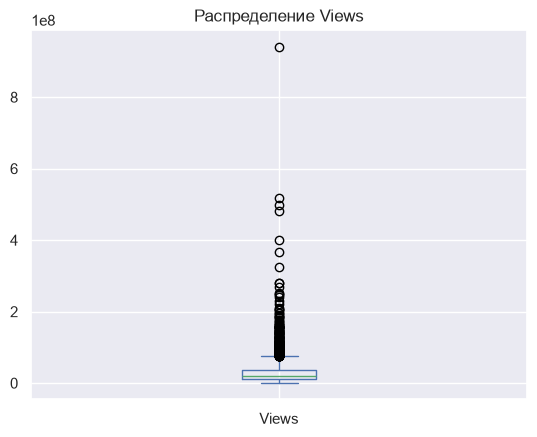

In [15]:
df['Views'].plot(kind='box')
plt.title('Распределение Views')
plt.show()

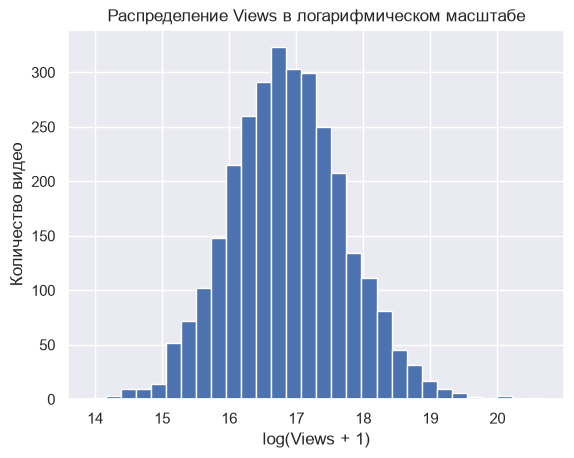

In [16]:
plt.hist(np.log1p(df['Views']), bins=30)
plt.title('Распределение Views в логарифмическом масштабе')
plt.xlabel('log(Views + 1)')
plt.ylabel('Количество видео')
plt.show()

Ввод: 
- Views имеет выраженную правостороннюю асимметрию: небольшая часть видео получает значительно больше просмотров, чем основная масса.
- Логарифмическое преобразование делает распределение более компактным и удобным для дальнейшего анализа.

**Проверяем экстремальные значения остальных метрик**

Для остальных признаков аналогично смотрим наблюдения выше верхней границы IQR:

In [17]:
for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    
    print(f'\n{col}')
    print(df[df[col] > upper][
        ['Video_ID', col]
    ].sort_values(col, ascending=False).head(5))


Views
      Video_ID      Views
1716  MB101716  941100445
2024  MB102024  517837880
2445  MB102445  497533501
1947  MB101947  482731088
2235  MB102235  400000000

Duration_Minutes
      Video_ID  Duration_Minutes
2984  MB102984             38.60
1340  MB101340             33.05
236   MB100236             32.59
2431  MB102431             31.33
2374  MB102374             30.40

CTR_Percentage
      Video_ID  CTR_Percentage
1745  MB101745           13.75
1738  MB101738           13.59
291   MB100291           13.36
1578  MB101578           12.77
2337  MB102337           12.69

Average_View_Duration
      Video_ID  Average_View_Duration
1862  MB101862                 1325.1
236   MB100236                 1302.9
1549  MB101549                 1302.0
1340  MB101340                 1287.4
695   MB100695                 1267.0

Engagement_Rate
      Video_ID  Engagement_Rate
2748  MB102748           11.140
387   MB100387           10.818
49    MB100049           10.636
580   MB100580         

**1. Views**

Максимум — 941 100 445 просмотров.

Также есть значения около 400–520 млн. Это действительно экстремальные наблюдения, но сами по себе они не выглядят как техническая ошибка: просмотры могут сильно различаться между видео.

Вывод: выбросы есть, но удалять их не нужно. Они могут быть как раз наиболее интересными для нашего анализа результативности.

**2. Duration_Minutes**

Максимум — 38.6 минут.

Для видео это вполне реалистичное значение.

Вывод: статистические выбросы есть, но значения выглядят правдоподобно.

**3. CTR_Percentage**

Максимум — 13.75%.

Это тоже выглядит реалистично.

Вывод: аномальных значений по бизнес-смыслу не видно.

**4. Average_View_Duration**

Здесь максимальные значения — примерно 1 325 секунд, то есть около 22 минут.

Вывод: статистические выбросы есть, но значения выглядят правдоподобно.

**5. Engagement_Rate**

Максимум — 11.14.

Так как признак выражается в процентах, то 11.14% выглядит нормально.

Вывод: статистические выбросы есть, но значения выглядят правдоподобно.


**6. Likes / Comments / Shares / Subscribers_Gained**

Здесь видны очень большие значения:

Likes — до 60,911,877;

Comments — до 1,969,900;

Shares — до 7,550,806;

Subscribers_Gained — до 1,274,819.




**Проверим логические ограничения для метрик вовлечённости**

In [20]:
df[
    (df['Likes'] > df['Views']) |
    (df['Comments'] > df['Views']) |
    (df['Shares'] > df['Views'])
][
    ['Video_ID', 'Views', 'Likes', 'Comments', 'Shares']
]

,Video_ID,Views,Likes,Comments,Shares


Вывод: логических нарушений для метрик вовлеченности не выявлено.

**Общие выводы:** 
- В числовых признаках выявлены статистические выбросы по методу IQR. **Наибольшее количество выбросов наблюдается в Views, Likes, Comments, Shares и Subscribers_Gained.**
- При этом наличие статистического выброса не означает ошибочность значения. **Для Views выявлена выраженная правосторонняя асимметрия распределения: небольшая доля видео имеет значительно больше просмотров, чем основная масса наблюдений.**
- **Дополнительная проверка экстремальных наблюдений показала, что они могут соответствовать реально успешным видео и поэтому не должны автоматически исключаться из анализа.**
- Корректные экстремальные значения сохраняем в датасете, поскольку они являются частью реального распределения показателей и могут иметь бизнес-значение. **При дальнейшем анализе учитываем асимметрию распределения Views и влияние экстремальных наблюдений на статистические показатели.**
- **Категориальные признаки и признаки даты мы проверяли ранее, аномальных значений не выявлено.**

## 4.6. Создание производных признаков

Я обнаружил, что в исходном датасете нет прямого показателя доли просмотренного видео (удержание), однако имеются:

- Duration_Minutes
- Average_View_Duration

Поэтому для более полного анализа создаем производный признак:

In [10]:
df['Average_Watch_Percentage'] = (
    df['Average_View_Duration']
    / 60
    / df['Duration_Minutes']
    * 100
)

Проверим

In [11]:
df['Average_Watch_Percentage'].describe()

count    3000.000000
mean       45.303112
std        14.926916
min         7.994078
25%        35.145142
50%        44.947106
75%        55.620779
max        95.006242
Name: Average_Watch_Percentage, dtype: float64

In [12]:
(df['Average_Watch_Percentage'] > 100).sum()

np.int64(0)

In [13]:
(df['Average_Watch_Percentage'] < 0).sum()

np.int64(0)

**Вывод: признак успешно создан.**

## 4.7. Заключение по проверкам и подготовке данных

- существенные **пропуски обнаружены только в столбце Sponsor**. Проверка данного признака выходит за рамки нашего исследования;
- **Полных дубликатов не обнаружено**;
- Тип данных **Upload_Date был приведён к формату datetime**;
- Для числовых признаков и их логических взаимосвязей нарушений допустимых диапазонов и логических условий не обнаружено;
- В признаках, связанных с датой и временем публикации, исправлена аномалия признака **Publish_Day**: при проверке его согласованности с Upload_Date обнаружено 2571 расхождение из 3000 записей (85,7%). Поэтому **исходный Publish_Day не используется в дальнейшем анализе. Для анализа дня недели создал корректный признак, рассчитанный непосредствено из Upload_Date;**
- **В категориальных и текстовых признаках** некорректных или неожиданных значений **не обнаружено;**
- Для **Video_ID подтверждена уникальность идентификаторов, пропусков и дубликатов нет;**
- При проверке аномальных значений **статистические выбросы выявлены** в нескольких числовых показателях. Однако они не были автоматически признаны ошибками: **анализ экстремальных наблюдений показал, что они могут отражать реальные успешные видео;**
Особенно выражена правосторонняя асимметрия Views, поэтому экстремальные значения просмотров сохраняются в датасете и будут учитываться при дальнейшем анализе;
- Также в виду важности такого признака, как удержание, на сонове имющихся признаков Duration_Minutes и Average_View_Duration создали новый признак Average_View_Duration.

**Итог: данные можно считать корректными для дальнейшего анализа.**

## 4.8. Итоговый дадасет

In [21]:
def prepare_data(df):
    
    df = df.copy()
    
    # 1. Преобразование типов
    df['Upload_Date'] = pd.to_datetime(df['Upload_Date'])
    
    # 2. Заменили дни публикаций, взяли их из Upload_Date
    df['Publish_Day'] = df['Upload_Date'].dt.day_name()

    # 3. Переводим среднюю длительность просмотра
    #    из секунд в минуты
    df['Average_View_Duration_Min'] = (
        df['Average_View_Duration'] / 60
    )
    
    # 4. Средняя доля просмотренного видео
    df['Average_Watch_Percentage'] = (
        df['Average_View_Duration_Min']
        / df['Duration_Minutes']
        * 100
    )
    
    return df

In [20]:
import numpy as np
df_plot = pd.read_csv(
    'C:/Users/user/Yandex.Disk/рабочее/projects/mrbeast_youtube_synthetic_dataset.csv'
)

df_plot = prepare_data(df)

print('Итоговый размер:', df.shape)

Итоговый размер: (3000, 37)


А также создадим датасет, где 2026 год уберем из анализа: 

In [19]:
df_without_2026 = df[df['Upload_Year'] < 2026].copy()

print('Размер исходного датасета:', df.shape)
print('Размер датасета для анализа:', df_without_2026.shape)
print('Годы в анализе:', sorted(df_without_2026['Upload_Year'].unique()))

Размер исходного датасета: (3000, 37)
Размер датасета для анализа: (2828, 37)
Годы в анализе: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


## Итог: 

- После завершения этапа проверки качества данных все подтверждённые преобразования  внесли в **датасет df_plot;**
- Для исследований, связанных с признаками года - используем **датасет df_without_2026.**

# 5. План аналитического исследования

**5.1. Основная метрика и направления анализа**

Views — основная метрика результативности видео.

Анализ проводим по четырём направлениям:

1)  Характеристики видео → Views
-  Duration_Minutes
- Video_Type
- Category
- CTR_Percentage
- Average_View_Duration
- Engagement_Rate
- Average_Watch_Percentage

2) Время публикации → Views
- Upload_Year
- Upload_Month
- Publish_Day
- Publish_Hour
- 
3) Вовлечённость → Views
- Likes
- Comments
- Shares
- Engagement_Rate

4) Рост аудитории → Views
- Subscribers_Gained

**5.2. Формирование исследовательских вопросов**

Исследовательские вопросы вытекают из 
1. Как характеристики видео связаны с количеством просмотров?
2. Связано ли время публикации с количеством просмотров?
3. Как показатели вовлечённости связаны с количеством просмотров?
4. Связан ли прирост подписчиков с количеством просмотров?

**5.3. Формирование направлений анализа**

1. Характеристики видео → Views.
2. Время публикации → Views.
3. CTR и удержание → Views.
4. Вовлечённость → Views.
5. Прирост подписчиков → Views.

**5.4. Выбор методов анализа**

Для числовых признаков используются визуальный анализ распределений, диаграммы рассеяния и корреляционный анализ.

Для категориальных признаков используются сравнение распределений и медианных значений между группами.

Для временных признаков используется сравнение результативности видео в зависимости от дня, часа, месяца и года публикации.

Выявленные закономерности в дальнейшем используются для формирования статистических гипотез и их проверки.

## 6. Исследовательский анализ данных (EDA)

**6.1. Распределение основной метрики Views**

Проверяем:

- количество наблюдений;
- минимальное и максимальное значение;
- среднее и медиану;
- квартили;
- разброс;
- асимметрию распределения;
- наличие экстремальных значений.

# Описательная статистика

In [46]:
desc = df_plot['Views'].describe()
print("Описательная статистика Views:")
print(desc)
print(f"\nMean:   {df_plot['Views'].mean():,.0f}")
print(f"Median: {df_plot['Views'].median():,.0f}")
print(f"Mean / Median ratio: {df_plot['Views'].mean() / df_plot['Views'].median():.2f}")

Описательная статистика Views:
count    3.000000e+03
mean     3.139421e+07
std      3.929370e+07
min      1.130081e+06
25%      1.178717e+07
50%      2.083981e+07
75%      3.696898e+07
max      9.411004e+08
Name: Views, dtype: float64

Mean:   31,394,211
Median: 20,839,806
Mean / Median ratio: 1.51


## Смотрим распределение

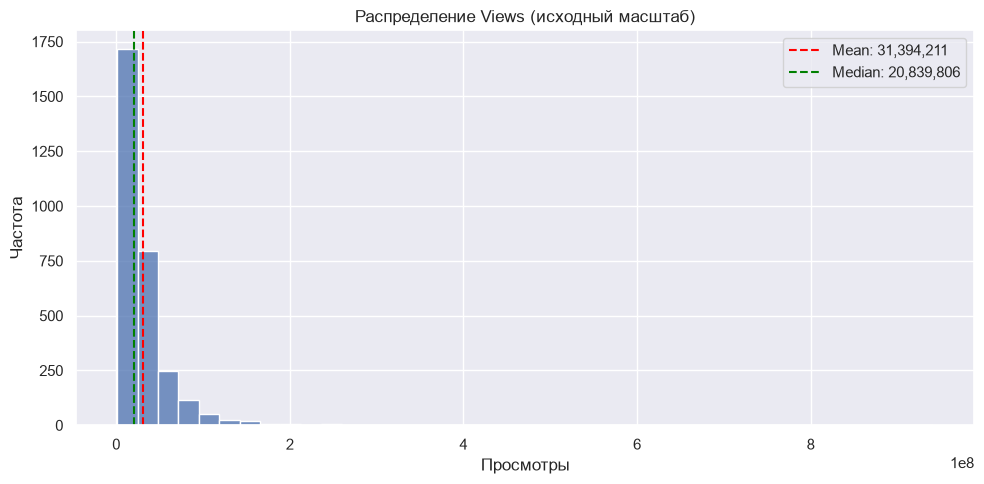

In [47]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df_plot['Views'], bins=40, ax=ax)
ax.axvline(df_plot['Views'].mean(), color='red', linestyle='--', label=f"Mean: {df_plot['Views'].mean():,.0f}")
ax.axvline(df_plot['Views'].median(), color='green', linestyle='--', label=f"Median: {df_plot['Views'].median():,.0f}")
ax.set_title('Распределение Views (исходный масштаб)')
ax.set_xlabel('Просмотры')
ax.set_ylabel('Частота')
ax.legend()
plt.tight_layout()
plt.show()


**Видим:**
- основная масса видео находится примерно до 50–60 млн Views;
- далее наблюдений становится резко меньше;
- присутствует длинный правый хвост;
- отдельные видео имеют существенно больше просмотров.

То есть распределение не является нормальным.

**Поскольку мы уже установили, что Views имеет правостороннюю асимметрию, дополнительно смотрим** 
## логарифмический масштаб

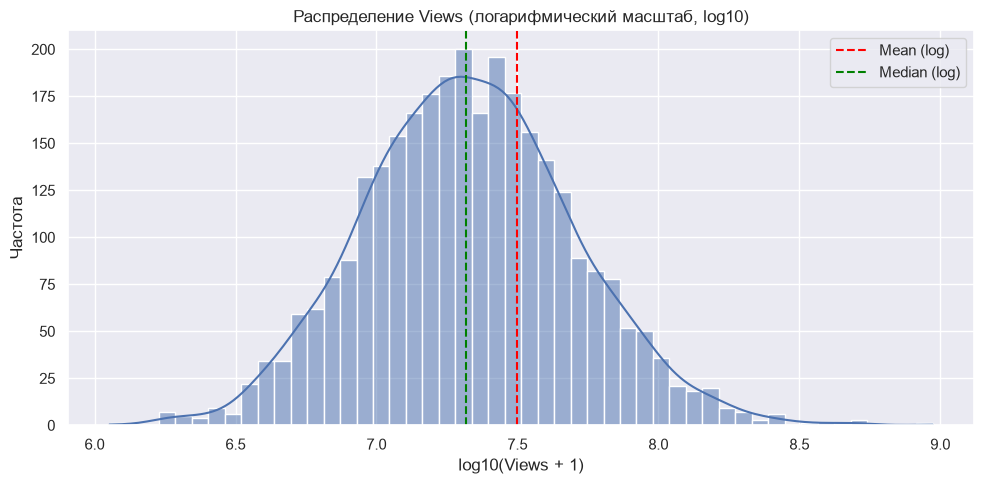

In [48]:
df_plot['Views_log'] = np.log10(df_plot['Views'] + 1)

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df_plot['Views_log'], bins=50, kde=True, ax=ax)
ax.axvline(np.log10(df_plot['Views'].mean() + 1), color='red', linestyle='--', label='Mean (log)')
ax.axvline(np.log10(df_plot['Views'].median() + 1), color='green', linestyle='--', label='Median (log)')
ax.set_title('Распределение Views (логарифмический масштаб, log10)')
ax.set_xlabel('log10(Views + 1)')
ax.set_ylabel('Частота')
ax.legend()
plt.tight_layout()
plt.show()

# Асимметрия

In [28]:
skew_raw = stats.skew(df_plot['Views'])
skew_log = stats.skew(df_plot['Views_log'])
print(f"\nИсходная шкала:  skewness = {skew_raw:.2f}")
print(f"Log-шкала:       skewness = {skew_log:.2f}")


Исходная шкала:  skewness = 7.85
Log-шкала:       skewness = 0.15


**Видим**, что логарифмическое преобразование (log10(Views+1)) существенно нормализует форму распределения:
- skewness снижается до 0.15;
- гистограмма визуально приближается к колоколообразной.

# Boxplot и выбросы (IQR-метод)


Верхняя граница (IQR-метод): 74,741,698
Количество выбросов (выше границы): 220 (7.3%)


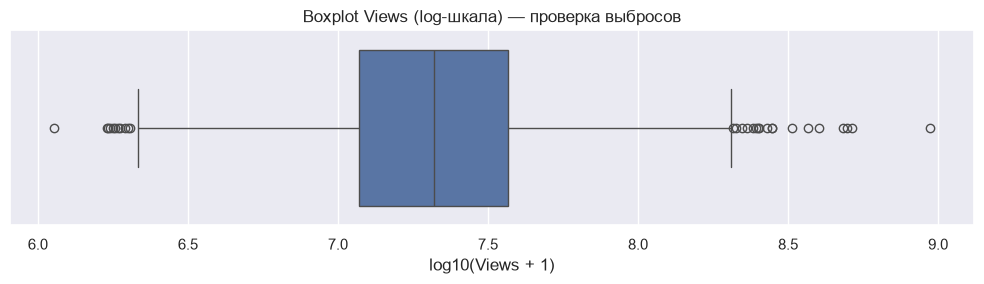

In [49]:
Q1 = df_plot['Views'].quantile(0.25)
Q3 = df_plot['Views'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

outliers = df_plot[df_plot['Views'] > upper_bound]
print(f"\nВерхняя граница (IQR-метод): {upper_bound:,.0f}")
print(f"Количество выбросов (выше границы): {len(outliers)} ({len(outliers) / len(df_plot) * 100:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 3))
sns.boxplot(x=df_plot['Views_log'], ax=ax)
ax.set_title('Boxplot Views (log-шкала) — проверка выбросов')
ax.set_xlabel('log10(Views + 1)')
plt.tight_layout()
plt.show()


**Видим:**
- 220 выбросов из 3000 наблюдений, это ≈ 7,3% всех видео;
- видео с Views выше примерно 74,75 млн классифицируются как статистические выбросы.

# QQ-plot: сравнение log(Views) с нормальным распределением

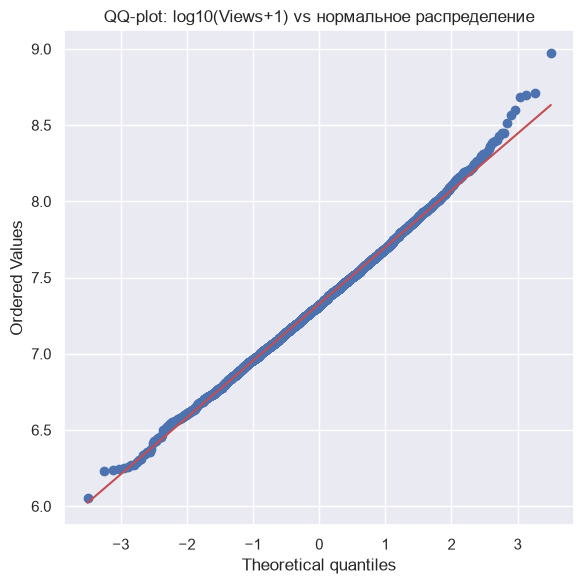

In [30]:
fig, ax = plt.subplots(figsize=(6, 6))
stats.probplot(df_plot['Views_log'], dist="norm", plot=ax)
ax.set_title('QQ-plot: log10(Views+1) vs нормальное распределение')
plt.tight_layout()
plt.show()

In [31]:
sample = df_plot['Views_log'].sample(min(5000, len(df_plot)), random_state=42)
shapiro_stat, shapiro_p = stats.shapiro(sample)
print(f"\nShapiro-Wilk test (log-шкала, выборка n={len(sample)}): stat={shapiro_stat:.4f}, p-value={shapiro_p:.4f}")


Shapiro-Wilk test (log-шкала, выборка n=3000): stat=0.9983, p-value=0.0034


**Видим, что**
- центральная часть распределения на QQ-plot ложится на теоретическую прямую почти идеально, но в верхнем хвосте (примерно верхние 5–10 значений) наблюдается заметное отклонение вверх от линии нормальности — то есть даже после логарифмирования правый хвост остаётся несколько тяжелее, чем предполагает нормальное распределение. Это указывает на то, что log(Views) приближается к нормальному распределению (логнормальное приближение для Views в исходной шкале), но не идеально, и экстремальные значения сохраняют повышенный вес;
- **тест Shapiro-Wilk (на подвыборке n=3000) отвергает гипотезу о нормальности (p = 0.0034).**

**Вывод:**
- Views имеет правостороннее асимметричное распределение, что подтверждается Skewness = 7,85, 
- Среднее значение (31,39 млн) существенно превышает медиану (20,84 млн) — отношение mean/median = 1.51.
- Подавляющее большинство видео сосредоточено в диапазоне до ~50–60 млн. просмотров, при этом отдельные видео достигают экстремальных значений (максимум ≈ 941М), формируя длинный правый хвост.
- Логарифмическое преобразование существенно нормализует форму распределения: skewness снижается до 0.15, гистограмма визуально приближается к колоколообразной. Однако формальный тест Shapiro-Wilk (на подвыборке n=3000) отвергает гипотезу о нормальности (p = 0.0034)
- Поэтому в дальнейшем для сравнения групп основной статистикой используем медиану Views;
- По правилу IQR выявлено 220 статистических выбросов (≈7,3%) выше верхней границы в 74.75 млн. просмотров, которые не удаляются, поскольку могут отражать реальные высокорезультативные видео.
- для статистической проверки гипотез (раздел 8) предпочтение отдаётся непараметрическим методам (Mann-Whitney, Kruskal-Wallis) вместо тестов, предполагающих нормальность — учитывая сохраняющееся отклонение в хвосте даже после логарифмирования;

## 6.2. Views и характеристики контента

Характеристики видео → Views
-  Duration_Minutes
- Video_Type
- Category
- CTR_Percentage
- Average_View_Duration
- Engagement_Rate
- Average_Watch_Percentage

## 6.2.1. Duration_Minutes → Views



count    3000.000000
mean       13.934290
std         5.901826
min         1.000000
25%         9.930000
50%        13.880000
75%        18.100000
max        38.600000
Name: Duration_Minutes, dtype: float64

Mean:   14
Median: 14
Mean / Median ratio: 1.00


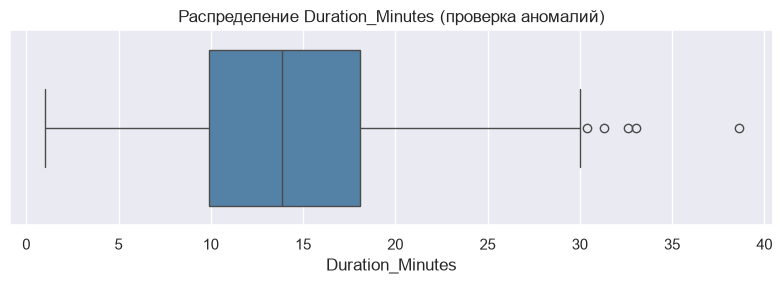

In [41]:
#  Проверка самого Duration_Minutes на аномалии
print(df_plot['Duration_Minutes'].describe())
print(f"\nMean:   {df_plot['Duration_Minutes'].mean():,.0f}")
print(f"Median: {df_plot['Duration_Minutes'].median():,.0f}")
print(f"Mean / Median ratio: {df_plot['Duration_Minutes'].mean() / df_plot['Duration_Minutes'].median():.2f}")

fig, ax = plt.subplots(figsize=(8, 3))
sns.boxplot(x=df_plot['Duration_Minutes'], ax=ax, color='steelblue')
ax.set_title('Распределение Duration_Minutes (проверка аномалий)')
plt.tight_layout()
plt.show()

Text(25.64127604166667, 0.5, 'Просмотры')

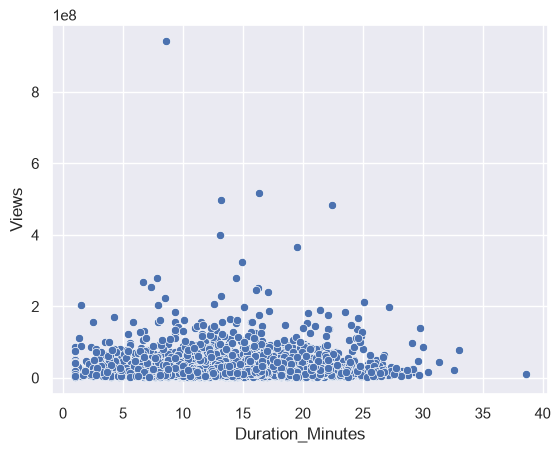

In [45]:
sns.scatterplot(
    data=df,
    x='Duration_Minutes',
    y='Views'
)

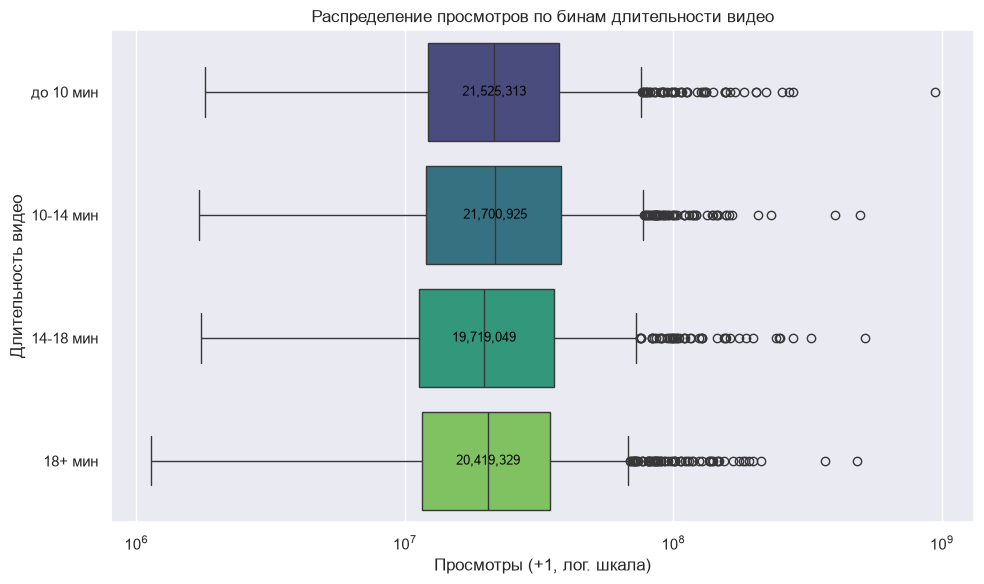

In [39]:

bins = [0, 10, 14, 18, np.inf]
labels = ['до 10 мин', '10-14 мин', '14-18 мин', '18+ мин']

df_plot['Duration_Bin'] = pd.cut(
    df_plot['Duration_Minutes'],
    bins=bins,
    labels=labels,
    right=False
)

fig, ax = plt.subplots(figsize=(10, 6))
order = labels

sns.boxplot(
    data=df_plot,
    x='Views_plus',
    y='Duration_Bin',
    order=order,
    hue='Duration_Bin',
    palette='viridis',
    legend=False,
    dodge=False,
    ax=ax
)

# Добавляем медианы текстом на график
medians = df_plot.groupby('Duration_Bin', observed=True)['Views_plus'].median()
for i, cat in enumerate(order):
    if cat in medians.index:
        ax.text(medians[cat], i, f'{int(medians[cat]):,}', 
                va='center', ha='center', color='black', fontsize=9)

ax.set_xscale('log')
ax.set_title('Распределение просмотров по бинам длительности видео')
ax.set_xlabel('Просмотры (+1, лог. шкала)')
ax.set_ylabel('Длительность видео')
plt.tight_layout()
plt.show()

In [32]:
# 4. Количественная оценка связи: Spearman и Pearson
# ---------------------------------------------------------
spearman_corr, spearman_p = spearmanr(df_plot['Duration_Minutes'], df_plot['Views'])
pearson_corr, pearson_p = pearsonr(df_plot['Duration_Minutes'], df_plot['Views'])

print(f"Spearman корреляция: {spearman_corr:.3f} (p-value = {spearman_p:.4f})")
print(f"Pearson корреляция:  {pearson_corr:.3f} (p-value = {pearson_p:.4f})")

Spearman корреляция: -0.028 (p-value = 0.1279)
Pearson корреляция:  -0.005 (p-value = 0.7672)


**Ключевые наблюдения:**
- Duration_Minutes сам по себе — чистая переменная.
Boxplot показывает симметричное распределение без серьёзных проблем: медиана 13.88, немного выбросов справа (видео длиннее ~30 минут), но это не критично и, вероятно, реальные длинные форматы, а не ошибки данных. Здесь всё в порядке, проверка пройдена.

- Scatter + LOWESS показывает практически горизонтальную линию — связи нет.
LOWESS-кривая почти не отклоняется от горизонтали на всём диапазоне от 0 до 38 минут, лёгкий спад к правому краю не выглядит содержательным (там же и меньше всего точек — доверие к кривой в этой зоне низкое). Купола или явного паттерна, который мы предполагали в гипотезе (короткие/длинные проседают, средние — в топе), не видно.

- Медианы по бинам почти идентичны.
21.5М → 21.7М → 19.7М → 20.4М — разброс меньше, чем в 1.1 раза. Для сравнения: у Video_Type разброс медиан был ~1.5 раза, у Category — ~1.15 раза. Duration_Minutes показывает даже более слабую связь, чем Category — то есть это, по всей видимости, самый слабый предиктор Views из всех, что мы разобрали пока.

- Коэффициенты корреляции подтверждают: связи практически нет.
Spearman = -0.028 (p=0.128), Pearson = -0.005 (p=0.767) — оба статистически незначимы (p > 0.05), оба близки к нулю. Это не "слабая, но реальная" связь — это отсутствие связи в пределах статистической погрешности.

## 6.2.2. Video_Type → Views



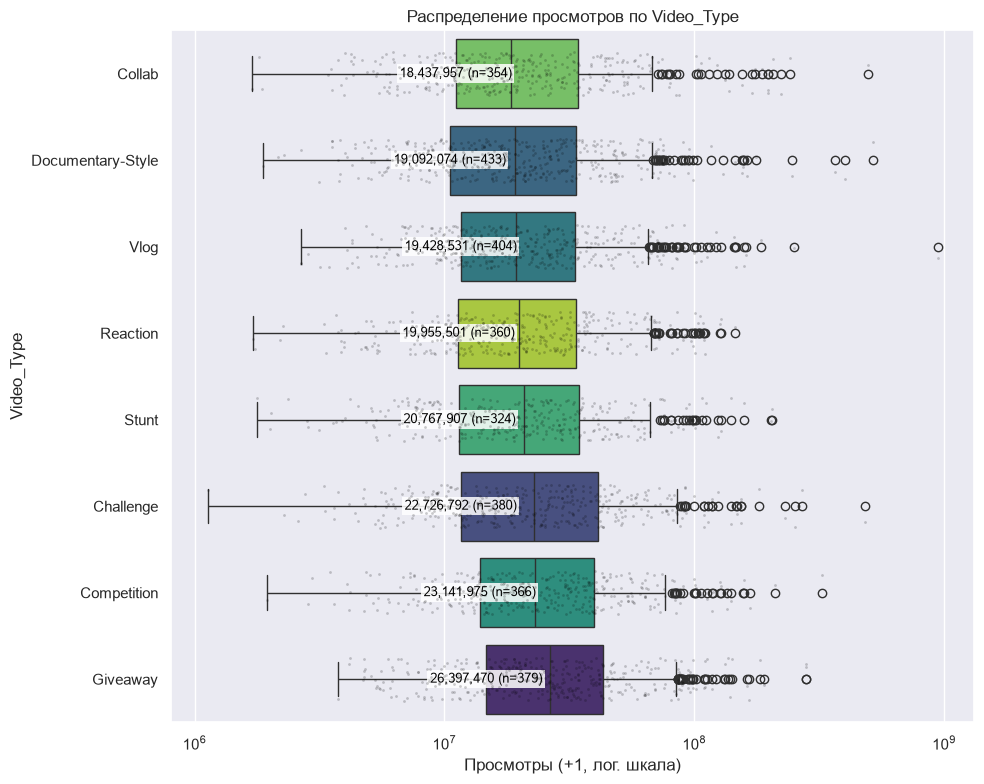

In [49]:
from scipy.stats import levene, kruskal

# ---------------------------------------------------------
# Подготовка
# ---------------------------------------------------------
df_plot = df.copy()
df_plot['Views_plus'] = df_plot['Views'] + 1

# Порядок категорий по медиане (по возрастанию)
order = (
    df_plot.groupby('Video_Type', observed=True)['Views_plus']
    .median()
    .sort_values()
    .index
    .tolist()
)

medians = df_plot.groupby('Video_Type', observed=True)['Views_plus'].median()
counts = df_plot['Video_Type'].value_counts()

# ---------------------------------------------------------
# 1. Boxplot
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 8))

sns.boxplot(
    data=df_plot,
    x='Views_plus',
    y='Video_Type',
    order=order,
    hue='Video_Type',
    palette='viridis',
    legend=False,
    dodge=False,
    ax=ax
)

for i, cat in enumerate(order):
    q1 = df_plot.loc[df_plot['Video_Type'] == cat, 'Views_plus'].quantile(0.25)
    n = counts.get(cat, 0)
    ax.text(
        q1, i,
        f'{int(medians[cat]):,} (n={n})',
        va='center', ha='center', color='black', fontsize=9,
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.85, pad=2)
    )

# Точки всех наблюдений
sns.stripplot(data=df_plot, y='Video_Type', x='Views_plus', order=order,
              color='black', alpha=0.2, size=2, jitter=0.25)

ax.set_xscale('log')
ax.set_title('Распределение просмотров по Video_Type')
ax.set_xlabel('Просмотры (+1, лог. шкала)')
ax.set_ylabel('Video_Type')
plt.tight_layout()
plt.show()

In [56]:
# Проверка гомогенности дисперсий (Levene's test)
groups = [df_plot.loc[df_plot['Video_Type'] == cat, 'Views_plus'] for cat in order]
levene_stat, levene_p = levene(*groups)
print(f"Levene's test: stat={levene_stat:.3f}, p-value={levene_p:.4f}")

if levene_p < 0.05:
    print("→ Дисперсии НЕ однородны → предпочтителен Kruskal-Wallis вместо ANOVA")
else:
    print("→ Дисперсии однородны → допустим classic ANOVA")

Levene's test: stat=1.176, p-value=0.3129
→ Дисперсии однородны → допустим classic ANOVA


In [55]:
# Предварительная непараметрическая проверка (Kruskal-Wallis)
kw_stat, kw_p = kruskal(*groups)
print(f"\nKruskal-Wallis test: stat={kw_stat:.3f}, p-value={kw_p:.4f}")


Kruskal-Wallis test: stat=40.300, p-value=0.0000


In [54]:
# Эффект-сайз
n_total = len(df_plot)
epsilon_squared = kw_stat / ((n_total**2 - 1) / (n_total + 1))
print(f"Epsilon-squared (effect size): {epsilon_squared:.4f}")

Epsilon-squared (effect size): 0.0134


**Вывод:**
- Video_Type статистически значимо связан с Views (Kruskal-Wallis, p<0.0001), при этом дисперсии групп однородны (Levene's test, p=0.313), что подтверждено формально, а не только визуально.
- Медианы образуют содержательно интерпретируемый градиент: форматы с встроенной механикой шеринга (Giveaway, Competition, Challenge) показывают более высокие медианные просмотры (22.7М–26.4М), чем личные/пассивные форматы (Collab, Documentary-Style — 18.4М–19.1М).
- Несмотря на статистическую значимость, размер эффекта мал - 0.0134 - связь статистически реальна, но по величине слабая, то есть Video_Type играет роль второстепенного, а не главного фактора.
- Размеры выборок по группам сбалансированы (n=324–433), что исключает искажение результата за счёт малочисленных категорий.

## 6.2.3.  Category → Views

C:\Users\user\AppData\Local\Temp\ipykernel_7428\4040391538.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df_plot, y='Category', x='Views_plus', order=order,


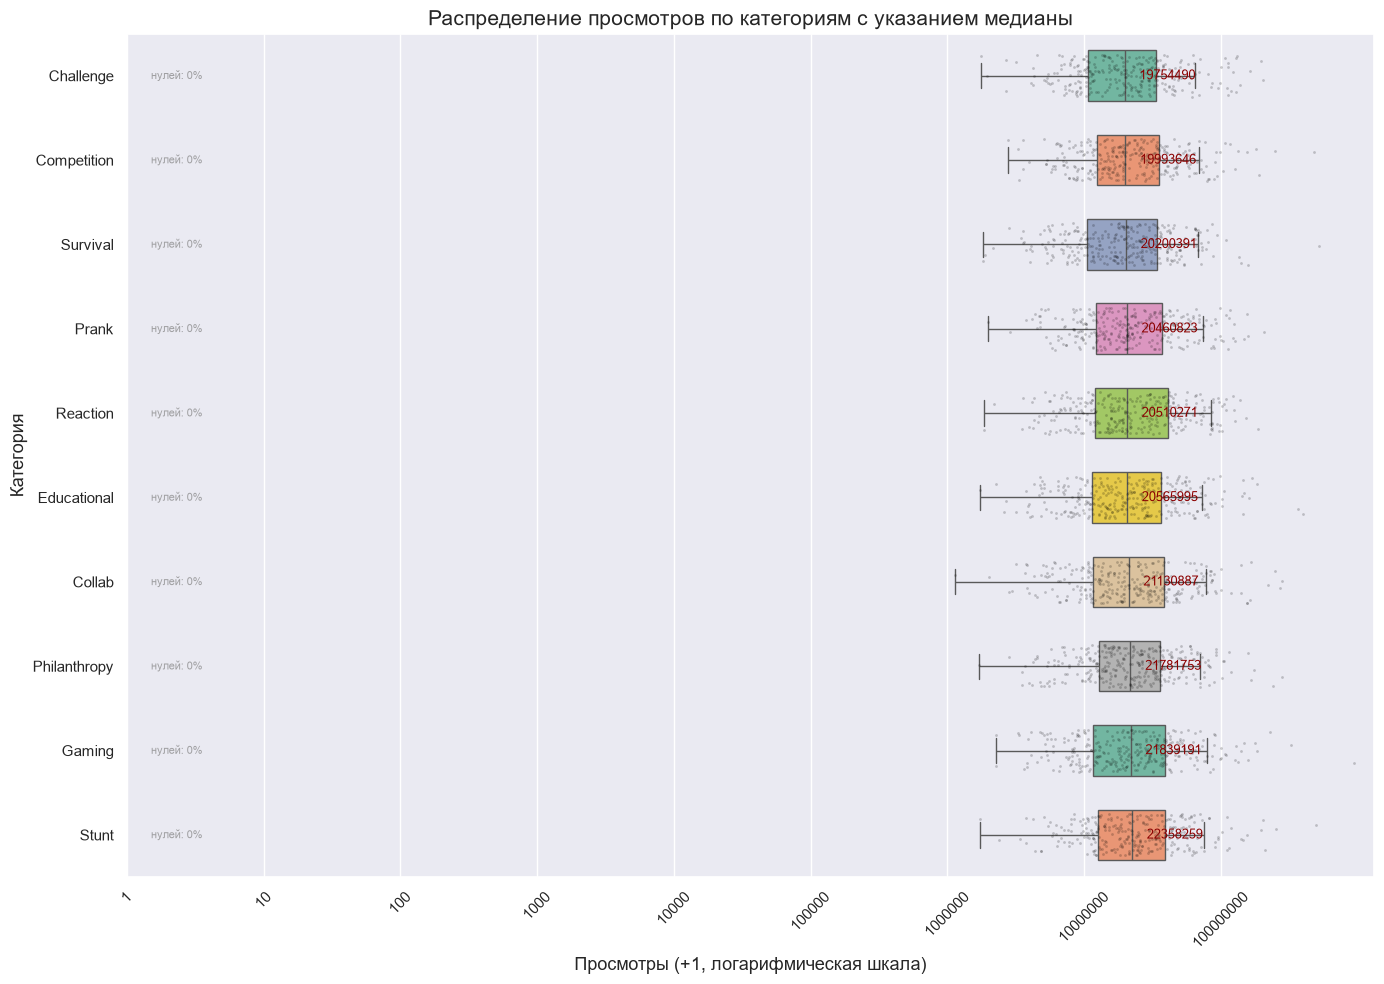

In [50]:
# Создаём копию данных с +1 для логарифма
df_plot = df.copy()
df_plot['Views_plus'] = df_plot['Views'] + 1

# Определяем порядок категорий по медиане
order = df_plot.groupby('Category')['Views_plus'].median().sort_values().index

plt.figure(figsize=(14, 10))
ax = sns.boxplot(data=df_plot, y='Category', x='Views_plus', order=order,
                 showfliers=False, palette='Set2', width=0.6)

# Точки всех наблюдений
sns.stripplot(data=df_plot, y='Category', x='Views_plus', order=order,
              color='black', alpha=0.2, size=2, jitter=0.25)

# Логарифмическая шкала
plt.xscale('log')
# Метки на оси X сделаем понятными (например, 1, 10, 100, 1000, ...)
xticks = [1, 10, 100, 1000, 10000, 100000, 1000000, 10000000, 100000000]
plt.xticks(xticks, labels=[f'{int(x)}' for x in xticks], rotation=45)

# Подписи медиан
medians = df_plot.groupby('Category')['Views_plus'].median().loc[order]
for i, med in enumerate(medians):
    ax.text(med * 1.2, i, f' {int(med)}', va='center', fontsize=9, color='darkred')

# Подписи долей нулей (оригинальные Views == 0)
zero_frac = df.groupby('Category')['Views'].apply(lambda x: (x == 0).mean())
for i, cat in enumerate(order):
    frac = zero_frac[cat]
    ax.text(1.5, i, f'нулей: {frac:.0%}', va='center', fontsize=8, color='gray', alpha=0.7)

plt.xlabel('Просмотры (+1, логарифмическая шкала)', fontsize=13)
plt.ylabel('Категория', fontsize=13)
plt.title('Распределение просмотров по категориям с указанием медианы', fontsize=15)
plt.tight_layout()
plt.show()

Вывод по разделу 6.2.3. Category → Views

Категория контента (Category) не демонстрирует выраженной связи с числом просмотров. Медианные значения Views по категориям находятся в узком диапазоне (~19.75М–22.36М), различаясь менее чем в 1.15 раза, при этом разброс значений внутри каждой категории охватывает 2–3 порядка. Это указывает на то, что внутригрупповая вариация существенно превышает межгрупповую, и Category в текущем виде — слабый кандидат в предикторы Views.

В отличие от Video_Type, где наблюдался как градиент медиан, так и рост дисперсии для форматов с встроенной механикой шеринга (Giveaway, Challenge, Competition), для Category подобной структурной логики не прослеживается: ширина боксов и уровень медиан визуально однородны по всем категориям, без явного смыслового упорядочивания.

Потенциальая гипотеза для проверки в разделе 8: статистически значимое различие медиан Views между категориями Category отсутствует, либо при большом объёме выборки будет выявлена формальная значимость (p < 0.05), но с пренебрежимо малым размером эффекта (epsilon-squared / eta-squared). В связи с визуально однородной дисперсией групп для проверки допустимо использовать классический ANOVA, при условии предварительной проверки на гомогенность дисперсий (Levene's test); при её нарушении — переход на Kruskal-Wallis.

Предварительный вывод: Category, вероятно, не войдёт в число ключевых факторов при формировании продуктовых рекомендаций и может рассматриваться как второстепенный/контрольный признак, в отличие от Video_Type, где структурная связь с вирусностью через встроенные механики шеринга выглядит более перспективной для дальнейшего анализа.





## 6.2.4. CTR_Percentage → Views




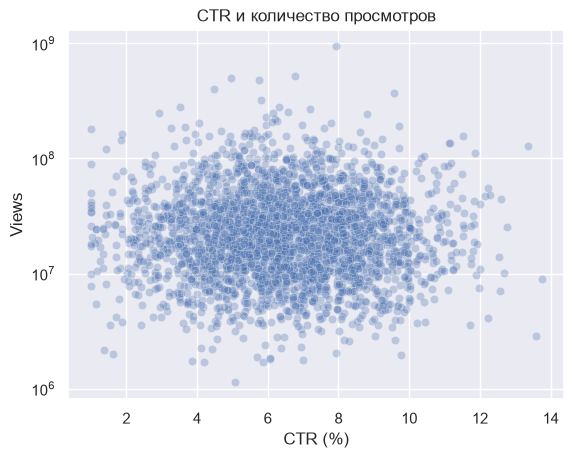

In [54]:
sns.scatterplot(
    data=df_plot,
    x='CTR_Percentage',
    y='Views', 
     alpha=0.3
)

plt.yscale('log')
plt.xlabel('CTR (%)')
plt.ylabel('Views')
plt.title('CTR и количество просмотров')
plt.show()

**Видим**:
- **На графике не наблюдается выраженной связи между CTR и количеством просмотров.** При одинаковых значениях CTR количество просмотров существенно варьируется;
- Основная масса наблюдений сосредоточена **при CTR около 4–9% и 10–100 млн просмотров.** Присутствуют отдельные экстремально популярные видео с сотнями миллионов и более просмотров.

Таким образом, CTR сам по себе не объясняет вариативность Views, поэтому **для дальнейшего анализа необходимо учитывать другие характеристики контента и показатели взаимодействия аудитории.**

## 6.2.5. Average_View_Duration → Views

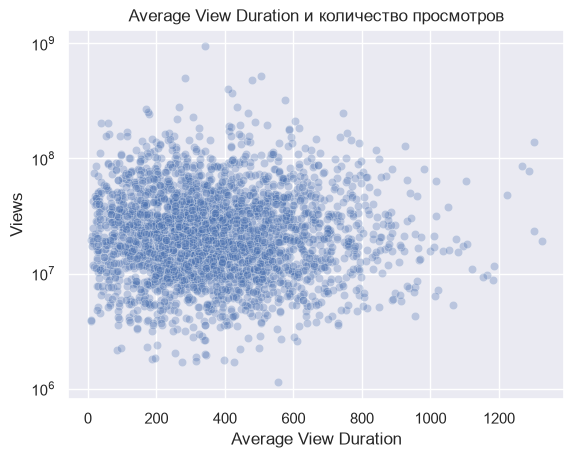

In [53]:
sns.scatterplot(
    data=df_plot,
    x='Average_View_Duration',
    y='Views',
    alpha=0.3
)

plt.yscale('log')
plt.xlabel('Average View Duration')
plt.ylabel('Views')
plt.title('Average View Duration и количество просмотров')
plt.show()

**Видим**:
- На графике **не наблюдается выраженной зависимости между Average_View_Duration и Views.**
- При одинаковой средней длительности просмотра количество просмотров существенно варьируется. Следовательно, абсолютная длительность просмотра не является достаточным объяснением вариативности Views.
- При этом показатель зависит от общей длительности видео, поэтому **для дальнейшего анализа целесообразно рассмотреть относительную долю просмотренного видео.**

## 6.2.6 Engagement_Rate → Views

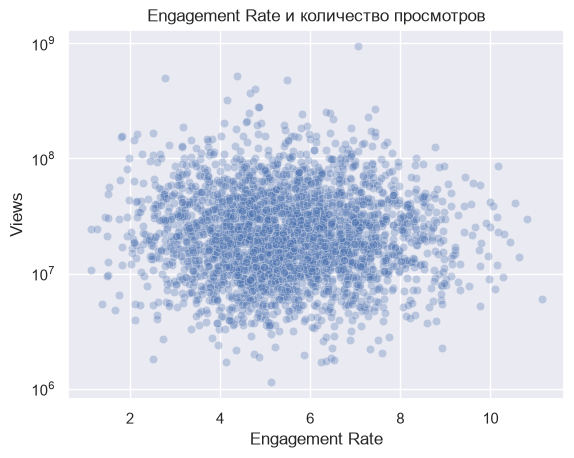

In [55]:
sns.scatterplot(
    data=df_plot,
    x='Engagement_Rate',
    y='Views',
    alpha=0.3
)

plt.yscale('log')

plt.xlabel('Engagement Rate')
plt.ylabel('Views')
plt.title('Engagement Rate и количество просмотров')
plt.show()

**Видим:**
- На графике не наблюдается выраженной зависимости между Engagement_Rate и Views. При близких значениях вовлечённости количество просмотров существенно различается. Следовательно, Engagement_Rate не является достаточным объяснением вариативности Views.

Также учтем, что математически возможна взаимосвязь Engagement_Rate и Views, поэтому интерпретация взаимосвязи требует дополнительной проверки формулы расчёта Engagement_Rate. 

Возможная формула рассчета: **Engagement_Rate = ((Likes+Comments+Shares)/Views)×100**

Проверим:


In [34]:
df_plot[['Engagement_Rate', 'Views', 'Likes', 'Comments', 'Shares']].head()

,Engagement_Rate,Views,Likes,Comments,Shares
0,6.994,12341699,788793,35498,76368
1,4.659,46571568,1622079,150824,210531
2,2.783,30479900,504615,162140,262712
3,7.609,5142975,312658,18200,38060
4,4.768,11753826,454661,44503,86519


In [36]:
df_plot['Engagement_Calc'] = (
    (df_plot['Likes'] + df_plot['Comments'] + df_plot['Shares']) 
    / df_plot['Views'] * 100
)

df_plot[['Engagement_Rate', 'Engagement_Calc']].head(10)

,Engagement_Rate,Engagement_Calc
0,6.994,7.297691
1,4.659,4.258895
2,2.783,3.049442
3,7.609,7.173241
4,4.768,4.982914
5,3.149,3.368352
6,4.019,3.756646
7,6.392,5.849541
8,6.551,6.182307
9,5.125,5.084171


In [37]:
df_plot['Engagement_Diff'] = (
   df_plot['Engagement_Rate'] - df_plot['Engagement_Calc']
)

df_plot['Engagement_Diff'].describe()

count    3000.000000
mean       -0.004438
std         0.330283
min        -0.894731
25%        -0.251256
50%        -0.004048
75%         0.248478
max         0.987485
Name: Engagement_Diff, dtype: float64

In [38]:
df_plot[['Engagement_Rate', 'Engagement_Calc']].corr()

,Engagement_Rate,Engagement_Calc
Engagement_Rate,1.000000,0.978403
Engagement_Calc,0.978403,1.000000


In [39]:
df_plot[['Engagement_Rate', 'Engagement_Calc']].describe()

,Engagement_Rate,Engagement_Calc
count,3000.000000,3000.000000
mean,5.480131,5.484569
std,1.597817,1.564695
min,1.137000,1.099512
25%,4.395250,4.393343
50%,5.405500,5.424636
75%,6.545000,6.536742
max,11.140000,10.471553


**Вывод:** 
- Между Engagement_Rate и Views не наблюдается выраженной визуальной зависимости. При этом проверка показала, что Engagement_Rate тесно связан с отношением суммарных взаимодействий к просмотрам (r = 0.978), однако показатели не совпадают полностью. Поэтому Engagement_Rate следует рассматривать как производную метрику вовлечённости, а не как независимый фактор, однозначно объясняющий количество просмотров.

## Views и характеристики контента, выводы: 
## - ни один отдельный признак характеристик контента визуально не показывает очевидной зависимости с Views.




## 6.3. Views и время публикации

## 6.3.1. Views по годам

Сначала смотрим, меняется ли медианное количество просмотров от года к году.
(Views обычно имеет сильную асимметрию: несколько очень популярных роликов могут сильно завысить среднее)

In [13]:
views_by_years = (
   df_without_2026.groupby('Upload_Year')['Views']
      .agg(['count', 'median', 'mean'])
      .reset_index()
)

views_by_years

,Upload_Year,count,median,mean
0,2018,349,11765325.0,1.666835e+07
1,2019,339,16085704.0,2.102053e+07
2,2020,341,16594135.0,2.384687e+07
3,2021,372,19225181.5,2.810429e+07
4,2022,355,23867931.0,3.224075e+07
5,2023,336,25492340.5,3.877897e+07
6,2024,368,26755268.5,3.661506e+07
7,2025,368,30115256.0,4.387876e+07


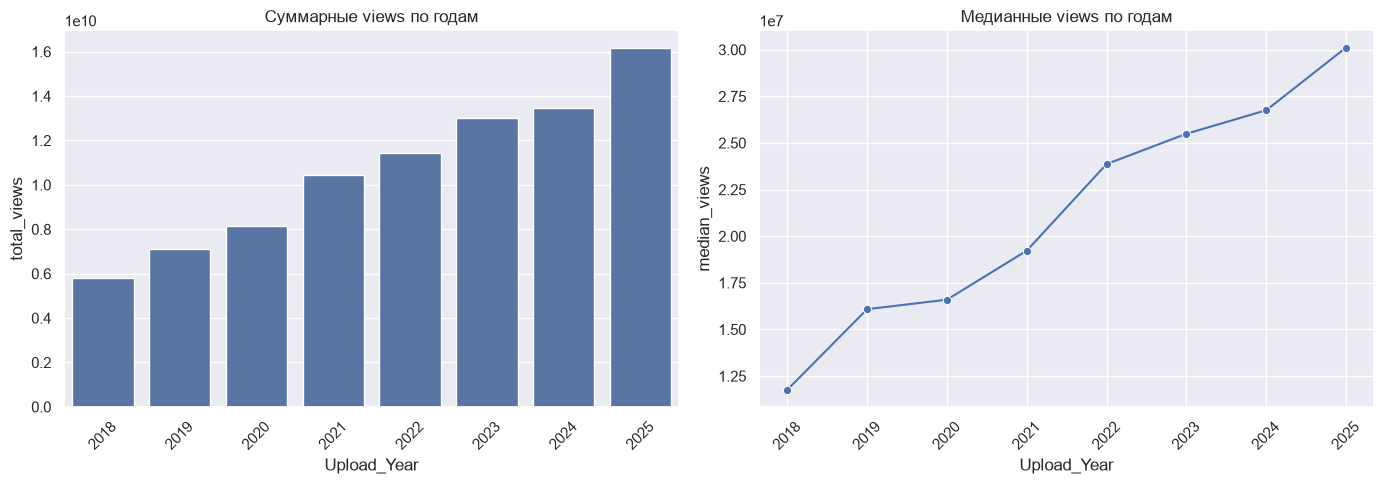

In [33]:
yearly_stats = df_without_2026.groupby('Upload_Year')['Views'].agg(
    total_views='sum',
    median_views='median',
    mean_views='mean',
    videos_count='count'
).reset_index()

yearly_stats['views_per_video'] = yearly_stats['total_views'] / yearly_stats['videos_count']

yearly_stats

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=yearly_stats, x='Upload_Year', y='total_views', ax=axes[0])
axes[0].set_title('Суммарные views по годам')
axes[0].tick_params(axis='x', rotation=45)

sns.lineplot(data=yearly_stats, x='Upload_Year', y='median_views', marker='o', ax=axes[1])
axes[1].set_title('Медианные views по годам')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Здесь наблюдается устойчивый восходящий тренд: медианные просмотры увеличиваются практически каждый год.

Особенно заметны:

2018 → 2019: +36,7%
2021 → 2022: +24,1%
2024 → 2025: +12,6%
В целом медианные просмотры выросли примерно в 3 раза: с 11,8 млн до 30,1млн.

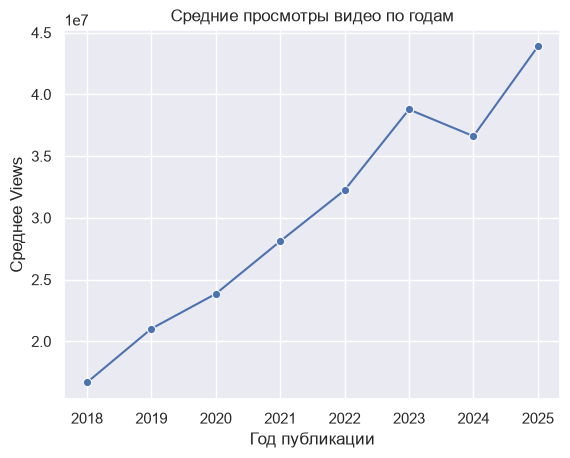

In [66]:
sns.lineplot(
    data=views_by_year,
    x='Upload_Year',
    y='mean',
    marker='o'
)

plt.title('Средние просмотры видео по годам')
plt.xlabel('Год публикации')
plt.ylabel('Среднее Views')
plt.show()

В отличие от медианы, среднее не растёт монотонно.

В 2024 году происходит небольшое снижение:

38,78 млн → 36,62 млн

То есть примерно −5,6%.

А затем:

2024 → 2025: рост примерно на 19,8%


**Вывод:**

- Медианное количество просмотров демонстрирует устойчивый восходящий тренд на протяжении 2018–2025гг.: с 11,8 млн в 2018 году до 30,1 млн. Таким образом, типичный уровень просмотров видео со временем существенно увеличивается.

- Среднее количество просмотров также показывает общий рост, однако динамика менее стабильна: в 2024 году наблюдается небольшое снижение по сравнению с 2023 годом, после чего показатель снова увеличивается. Различие между динамикой среднего и медианного значения подтверждает влияние высокопросмотровых видео на среднее значение Views.


## 6.3.2. Views по месяцам

Здесь важно не просто построить groupby('Upload_Month'), а учитывать, что количество публикаций в разные месяцы может отличаться.

In [45]:
views_by_month = (
   df_without_2026.groupby('Upload_Month')['Views']
      .agg(['count', 'median', 'mean'])
      .reset_index()
)

views_by_month

,Upload_Month,count,median,mean
0,1,240,20949086.5,3.851708e+07
1,2,190,18976298.0,2.760423e+07
2,3,262,20614019.0,2.954518e+07
3,4,235,18854329.0,2.979085e+07
4,5,238,19085655.5,2.673274e+07
5,6,244,18539098.5,2.927640e+07
6,7,250,20876137.0,2.807820e+07
7,8,250,22046509.5,2.759718e+07
8,9,243,21052675.0,3.129659e+07
9,10,233,20687706.0,3.306046e+07


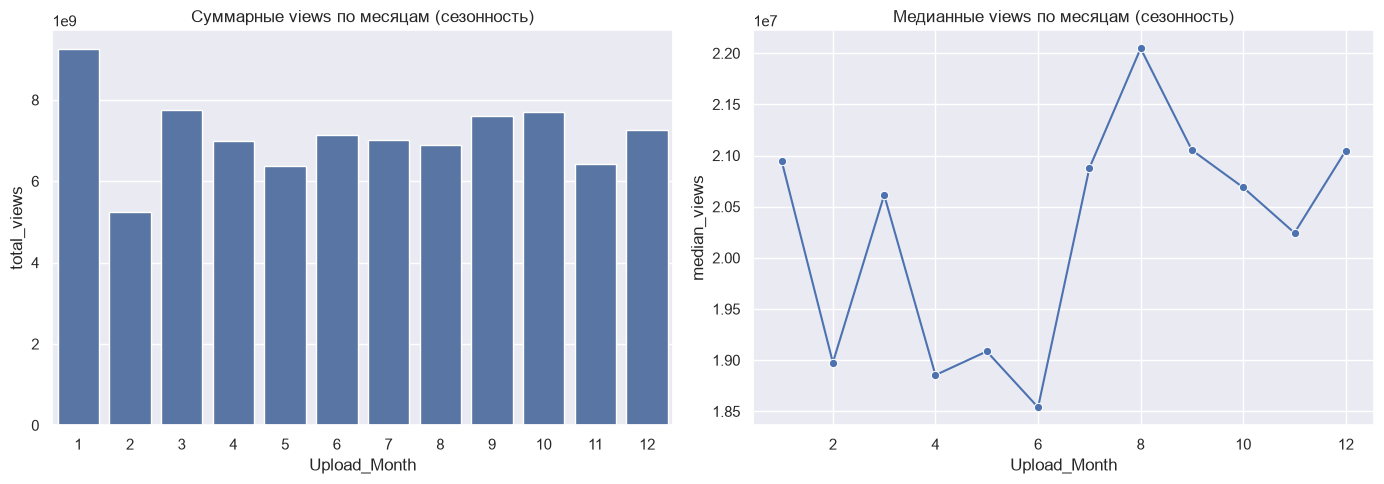

In [46]:
monthly_stats = df_without_2026.groupby('Upload_Month')['Views'].agg(
    total_views='sum',
    median_views='median',
    mean_views='mean',
    videos_count='count'
).reset_index()

monthly_stats['views_per_video'] = monthly_stats['total_views'] / monthly_stats['videos_count']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=monthly_stats, x='Upload_Month', y='total_views', ax=axes[0])
axes[0].set_title('Суммарные views по месяцам (сезонность)')

sns.lineplot(data=monthly_stats, x='Upload_Month', y='median_views', marker='o', ax=axes[1])
axes[1].set_title('Медианные views по месяцам (сезонность)')

plt.tight_layout()
plt.show()

- разброс медианы небольшой
- выраженной сезонности по месяцам нет. Это подтверждает: сам по себе календарный месяц публикации — слабый фактор.

Посмотрим, как менялись просмотры месяц за месяцем на всём периоде

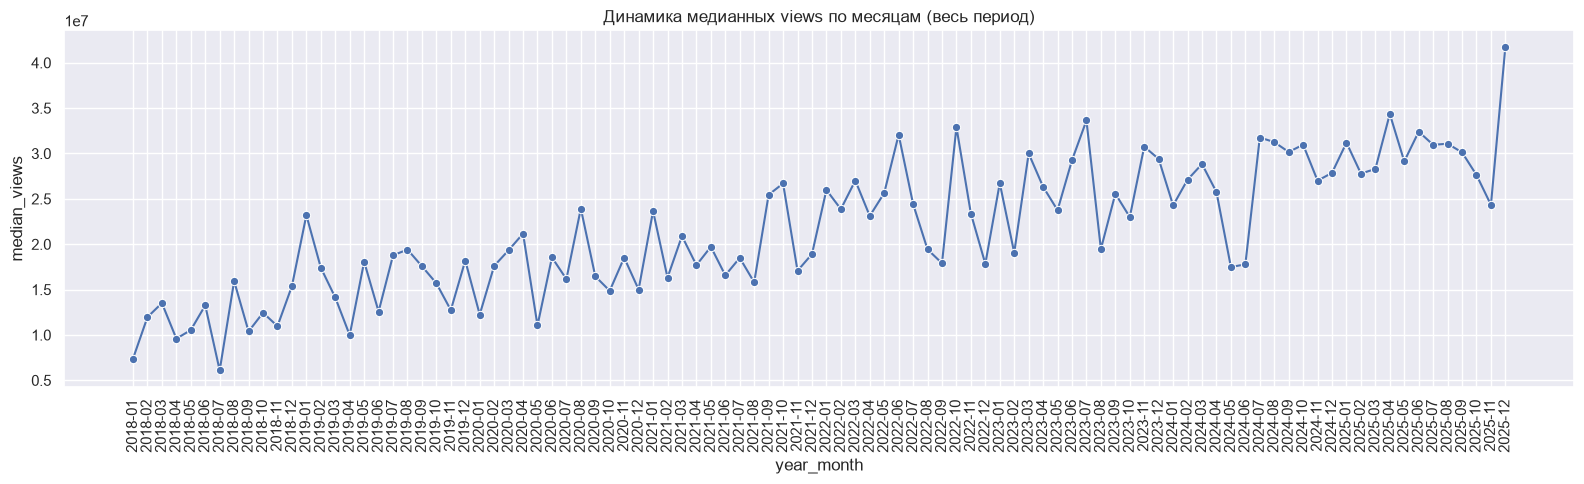

In [44]:

df_without_2026['year_month'] = df_without_2026['Upload_Year'].astype(str) + '-' + df_without_2026['Upload_Month'].astype(str).str.zfill(2)

trend_stats = df_without_2026.groupby('year_month')['Views'].agg(
    total_views='sum',
    median_views='median'
).reset_index().sort_values('year_month')

plt.figure(figsize=(16, 5))
sns.lineplot(data=trend_stats, x='year_month', y='median_views', marker='o')
plt.title('Динамика медианных views по месяцам (весь период)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Видно чёткий растущий тренд медианных views с 2018 по 2025:

- 2018–2019: медиана колеблется в районе 10–20M;
- 2020–2022: поднимается до 20–30M;
- 2023–2025: держится в районе 25–35M;
начало 2026: резкий скачок до 40–50M.

Плюс заметна пилообразная колебательность внутри каждого года (видно повторяющийся паттерн подъём-спад).  

Раз есть выраженный рост во времени, сделаем нормировку — разделим views на скользящее среднее по году или посчитаем "относительный" показатель:

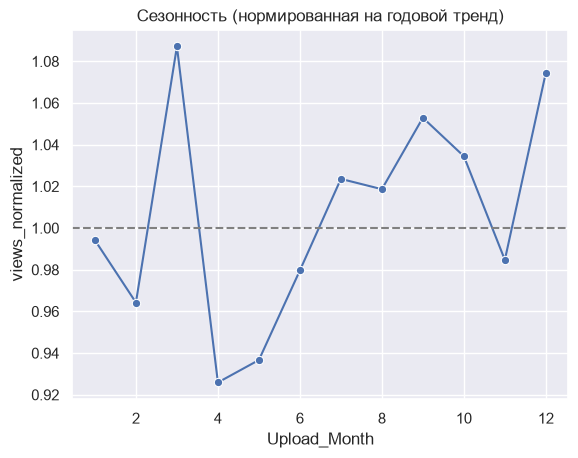

In [51]:
yearly_median = df_plot.groupby('Upload_Year')['Views'].transform('median')
df_plot['views_normalized'] = df_plot['Views'] / yearly_median

seasonality_normalized = df_plot.groupby('Upload_Month')['views_normalized'].median().reset_index()
sns.lineplot(data=seasonality_normalized, x='Upload_Month', y='views_normalized', marker='o')
plt.title('Сезонность (нормированная на годовой тренд)')
plt.axhline(1, color='gray', linestyle='--')
plt.show()

Видим, что после устранения общего тренда сезонность оказывается более выраженной и структурированной — есть два подъёма (март и конец года, особенно декабрь) и два спада (апрель и, слабее, май–июнь). Это уже похоже на реальный поведенческий паттерн.

**Выводы:**

- Сезонность по календарному месяцу публикации — слабая, не главный фактор;
- Есть выраженный долгосрочный тренд роста views (2018→2025), который является гораздо более сильным эффектом, чем сезонность;
- После нормировки видим реальный поведенческий паттерн: в период "сезонности" наблюдается рост просмотров.

## 6.3.3. Views по дням недели

In [45]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

df_without_2026['Publish_Day'] = pd.Categorical(df_without_2026['Publish_Day'], categories=day_order, ordered=True)

# Дополнительный признак — пригодится для сравнения будни/выходные
df_without_2026['Is_Weekend'] = df_without_2026['Publish_Day'].isin(['Saturday', 'Sunday'])

In [ ]:
day_stats = df.groupby('Publish_Day', observed=True).agg(
    median_views=('Views', 'median'),
    mean_views=('Views', 'mean'),
    video_count=('Views', 'count')
).reset_index()

day_stats

In [46]:
day_stats = df.groupby('Publish_Day', observed=True).agg(
    median_views=('Views', 'median'),
    mean_views=('Views', 'mean'),
    video_count=('Views', 'count')
).reset_index()

day_stats

,Publish_Day,median_views,mean_views,video_count
0,Monday,22571994.5,3.259334e+07,378
1,Tuesday,20032846.0,3.119008e+07,400
2,Wednesday,19482047.0,2.892843e+07,455
3,Thursday,20023559.0,3.085098e+07,493
4,Friday,21150009.5,3.050655e+07,420
5,Saturday,20851824.0,3.125523e+07,449
6,Sunday,23606918.0,3.498271e+07,405


In [47]:
weekend_stats = df.groupby('Is_Weekend').agg(
    median_views=('Views', 'median'),
    mean_views=('Views', 'mean'),
    video_count=('Views', 'count')
).reset_index()

weekend_stats['Is_Weekend'] = weekend_stats['Is_Weekend'].map({True: 'Weekend', False: 'Weekday'})
weekend_stats

,Is_Weekend,median_views,mean_views,video_count
0,Weekday,20460822.0,3.074606e+07,2146
1,Weekend,22024751.5,3.302295e+07,854


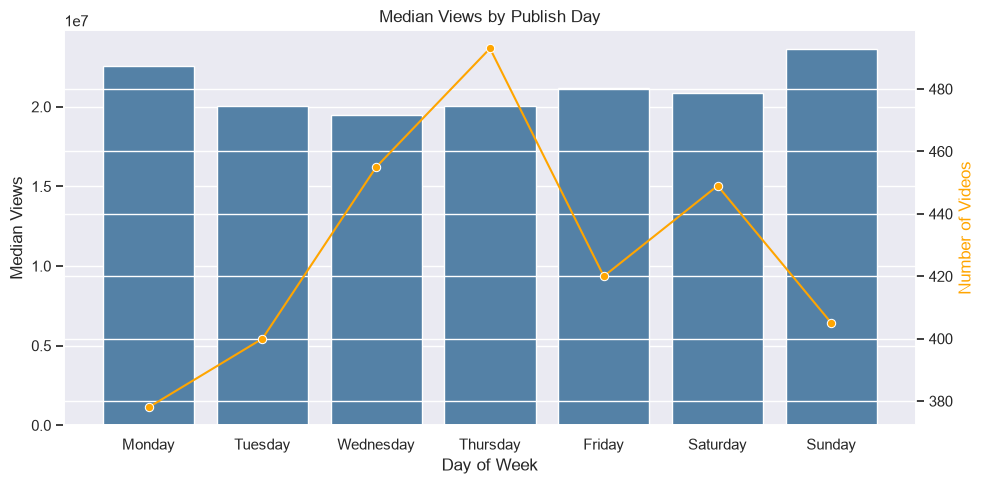

In [49]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# Основной barplot по медиане Views
sns.barplot(data=day_stats, x='Publish_Day', y='median_views', ax=ax1, color='steelblue')
ax1.set_ylabel('Median Views')
ax1.set_xlabel('Day of Week')
ax1.set_title('Median Views by Publish Day')

# Вторая ось — количество видео, чтобы видеть надёжность выборки
ax2 = ax1.twinx()
sns.lineplot(data=day_stats, x='Publish_Day', y='video_count', ax=ax2, color='orange', marker='o')
ax2.set_ylabel('Number of Videos', color='orange')

plt.tight_layout()
plt.show()

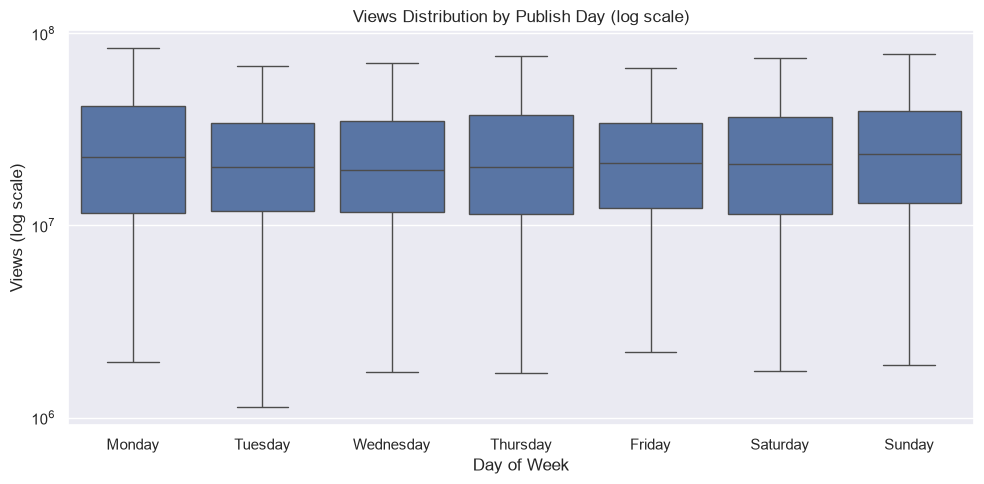

In [50]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Publish_Day', y='Views', order=day_order, showfliers=False)
plt.yscale('log')  # обычно нужен log, т.к. Views сильно skewed
plt.title('Views Distribution by Publish Day (log scale)')
plt.xlabel('Day of Week')
plt.ylabel('Views (log scale)')
plt.tight_layout()
plt.show()

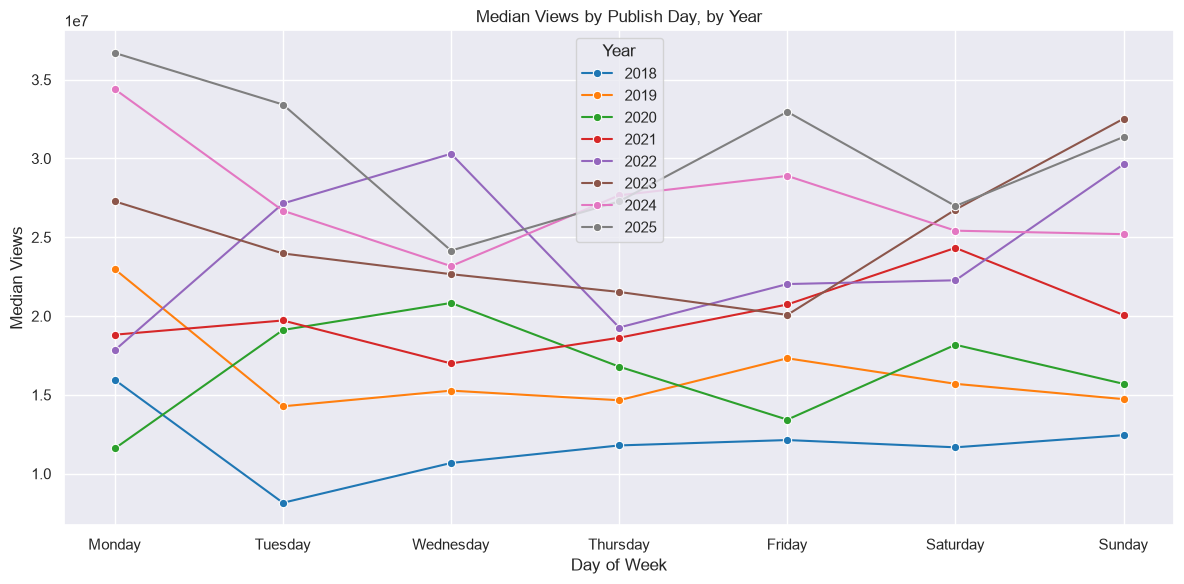

In [53]:
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=year_day_stats,
    x='Publish_Day',
    y='median_views',
    hue='Upload_Year',
    marker='o',
    palette='tab10'
)
plt.title('Median Views by Publish Day, by Year')
plt.xlabel('Day of Week')
plt.ylabel('Median Views')
plt.legend(title='Year')
plt.tight_layout()
plt.show()

In [64]:
year_day_stats = df_without_2026.groupby(['Upload_Year', 'Publish_Day'], observed=True).agg(
    median_views=('Views', 'median'),
    video_count=('Views', 'count')
).reset_index()

year_day_stats['rank'] = year_day_stats.groupby('Upload_Year')['median_views'].rank(ascending=False)

rank_pivot = year_day_stats.pivot(index='Publish_Day', columns='Upload_Year', values='rank')
rank_pivot = rank_pivot.reindex(day_order)

rank_pivot

Upload_Year,2018,2019,2020,2021,2022,2023,2024,2025
Publish_Day,,,,,,,,
Monday,1.0,1.0,7.0,5.0,7.0,2.0,1.0,1.0
Tuesday,7.0,7.0,2.0,4.0,3.0,4.0,4.0,2.0
Wednesday,6.0,4.0,1.0,7.0,1.0,5.0,7.0,7.0
Thursday,4.0,6.0,4.0,6.0,6.0,6.0,3.0,5.0
Friday,3.0,2.0,6.0,2.0,5.0,7.0,2.0,3.0
Saturday,5.0,3.0,3.0,1.0,4.0,3.0,5.0,6.0
Sunday,2.0,5.0,5.0,3.0,2.0,1.0,6.0,4.0


In [65]:
for i in range(len(years)):
    for j in range(i+1, len(years)):
        y1, y2 = years[i], years[j]
        vals1 = rank_pivot[y1]
        vals2 = rank_pivot[y2]
        corr, p = spearmanr(vals1, vals2)
        print(f"{y1} vs {y2}: Spearman r = {corr:.2f}, p = {p:.3f}")

2018 vs 2019: Spearman r = 0.61, p = 0.148
2018 vs 2020: Spearman r = -0.93, p = 0.003
2018 vs 2021: Spearman r = 0.14, p = 0.760
2018 vs 2022: Spearman r = -0.54, p = 0.215
2018 vs 2023: Spearman r = 0.36, p = 0.432
2018 vs 2024: Spearman r = 0.50, p = 0.253
2018 vs 2025: Spearman r = 0.43, p = 0.337
2019 vs 2020: Spearman r = -0.61, p = 0.148
2019 vs 2021: Spearman r = 0.25, p = 0.589
2019 vs 2022: Spearman r = -0.43, p = 0.337
2019 vs 2023: Spearman r = 0.07, p = 0.879
2019 vs 2024: Spearman r = 0.43, p = 0.337
2019 vs 2025: Spearman r = 0.18, p = 0.702
2020 vs 2021: Spearman r = -0.29, p = 0.535
2020 vs 2022: Spearman r = 0.71, p = 0.071
2020 vs 2023: Spearman r = -0.18, p = 0.702
2020 vs 2024: Spearman r = -0.75, p = 0.052
2020 vs 2025: Spearman r = -0.64, p = 0.119
2021 vs 2022: Spearman r = -0.07, p = 0.879
2021 vs 2023: Spearman r = 0.18, p = 0.702
2021 vs 2024: Spearman r = 0.11, p = 0.819
2021 vs 2025: Spearman r = 0.14, p = 0.760
2022 vs 2023: Spearman r = 0.14, p = 0.760
20

**Вывод**
- По дням недели: самая высокая медиана Views — воскресенье (23.6 млн) и понедельник (22.6 млн),
самая низкая — среда (19.5 млн). Разброс между максимумом и минимумом ~20% — заметная, но не драматическая разница;

- Будни vs выходные: Weekend медиана 22.0 млн, Weekday медиана 20.5 млн,
выходные видео собирают примерно на 7-8% больше просмотров по медиане;
- Количество публикаций (оранжевая линия): меньше всего видео публикуют по понедельникам (378) — при этом именно понедельник входит в топ по просмотрам, больше всего — по четвергам (493), но у четверга просмотры близки к среднему;
- Разница между днями есть, но не экстремальная (~20% между крайними точками), что паттерн умеренный, а не резкий
- Выходные дают небольшое преимущество по просмотрам — логично объясняется тем, что у зрителей больше свободного времени
- Boxplot показывает, что распределения сильно перекрываются между всеми днями — медианы отличаются, но разброс (IQR) везде примерно одинаковый, значит день публикации — не решающий фактор, а один из многих
-  Дни с наименьшим количеством публикаций (понедельник, вторник) показывают одни из лучших медиан по просмотрам, а день с наибольшим числом публикаций (четверг) — просмотры около среднего. Это может говорить о том, что в дни с меньшей конкуренцией за внимание зрителя (меньше новых видео) отдельное видео получает больше шансов быть замеченным — но это уже гипотеза, а не доказанный факт (корреляция, не причинность — хорошо бы явно это оговорить в тексте);
-  Видим, что линии "гуляют" в разные стороны год от года. Делаем вывод - это шум, и день недели не стоит выделять как значимый фактор, что также подтверждается отсутсвием корреляции. 


## 6.3.4. Views по часам публикации

In [59]:
hour_stats = df_without_2026.groupby('Publish_Hour', observed=True).agg(
    median_views=('Views', 'median'),
    mean_views=('Views', 'mean'),
    video_count=('Views', 'count')
).reset_index().sort_values('Publish_Hour')

hour_stats

,Publish_Hour,median_views,mean_views,video_count
0,0,20727918.0,3.145389e+07,132
1,1,18608408.0,2.529316e+07,98
2,2,18132996.0,2.625608e+07,117
3,3,19640245.5,2.719481e+07,108
4,4,20722748.0,3.140964e+07,108
5,5,23020588.0,2.846949e+07,131
6,6,20670428.0,2.948283e+07,102
7,7,17473605.0,2.845614e+07,111
8,8,17623555.0,2.666907e+07,103
9,9,24378555.0,3.037528e+07,126


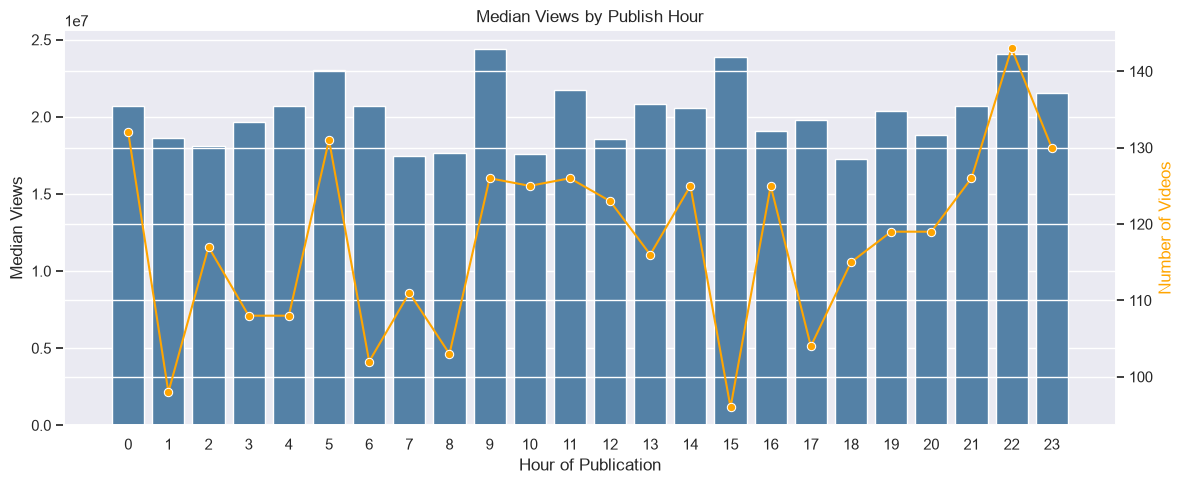

In [60]:
fig, ax1 = plt.subplots(figsize=(12, 5))

sns.barplot(data=hour_stats, x='Publish_Hour', y='median_views', ax=ax1, color='steelblue')
ax1.set_ylabel('Median Views')
ax1.set_xlabel('Hour of Publication')
ax1.set_title('Median Views by Publish Hour')

ax2 = ax1.twinx()
sns.lineplot(data=hour_stats, x='Publish_Hour', y='video_count', ax=ax2, color='orange', marker='o')
ax2.set_ylabel('Number of Videos', color='orange')

plt.tight_layout()
plt.show()

In [61]:
def get_time_of_day(hour):
    if 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 18:
        return 'Afternoon'
    elif 18 <= hour < 24:
        return 'Evening'
    else:
        return 'Night'

df_without_2026['Time_of_Day'] = df_without_2026['Publish_Hour'].apply(get_time_of_day)

tod_order = ['Morning', 'Afternoon', 'Evening', 'Night']
df_without_2026['Time_of_Day'] = pd.Categorical(df_without_2026['Time_of_Day'], categories=tod_order, ordered=True)

tod_stats = df_without_2026.groupby('Time_of_Day', observed=True).agg(
    median_views=('Views', 'median'),
    video_count=('Views', 'count')
).reset_index()

tod_stats

,Time_of_Day,median_views,video_count
0,Morning,19989259.0,693
1,Afternoon,20424400.0,689
2,Evening,20571520.5,752
3,Night,19714371.5,694


In [62]:
year_tod_stats = df_without_2026.groupby(['Upload_Year', 'Time_of_Day'], observed=True).agg(
    median_views=('Views', 'median')
).reset_index()

year_tod_stats['rank'] = year_tod_stats.groupby('Upload_Year')['median_views'].rank(ascending=False)

rank_pivot_tod = year_tod_stats.pivot(index='Time_of_Day', columns='Upload_Year', values='rank')
rank_pivot_tod = rank_pivot_tod.reindex(tod_order)

rank_pivot_tod

Upload_Year,2018,2019,2020,2021,2022,2023,2024,2025
Time_of_Day,,,,,,,,
Morning,1.0,3.0,3.0,2.0,2.0,3.0,3.0,4.0
Afternoon,4.0,4.0,1.0,3.0,1.0,2.0,4.0,3.0
Evening,3.0,1.0,4.0,4.0,4.0,1.0,1.0,2.0
Night,2.0,2.0,2.0,1.0,3.0,4.0,2.0,1.0


In [63]:
years = sorted(df_without_2026['Upload_Year'].unique())
for i in range(len(years)):
    for j in range(i+1, len(years)):
        y1, y2 = years[i], years[j]
        corr, p = spearmanr(rank_pivot_tod[y1], rank_pivot_tod[y2])
        print(f"{y1} vs {y2}: Spearman r = {corr:.2f}, p = {p:.3f}")

2018 vs 2019: Spearman r = 0.20, p = 0.800
2018 vs 2020: Spearman r = -0.40, p = 0.600
2018 vs 2021: Spearman r = 0.60, p = 0.400
2018 vs 2022: Spearman r = -0.20, p = 0.800
2018 vs 2023: Spearman r = -0.60, p = 0.400
2018 vs 2024: Spearman r = 0.20, p = 0.800
2018 vs 2025: Spearman r = -0.20, p = 0.800
2019 vs 2020: Spearman r = -0.80, p = 0.200
2019 vs 2021: Spearman r = -0.20, p = 0.800
2019 vs 2022: Spearman r = -1.00, p = 0.000
2019 vs 2023: Spearman r = 0.20, p = 0.800
2019 vs 2024: Spearman r = 1.00, p = 0.000
2019 vs 2025: Spearman r = 0.60, p = 0.400
2020 vs 2021: Spearman r = 0.40, p = 0.600
2020 vs 2022: Spearman r = 0.80, p = 0.200
2020 vs 2023: Spearman r = -0.40, p = 0.600
2020 vs 2024: Spearman r = -0.80, p = 0.200
2020 vs 2025: Spearman r = 0.00, p = 1.000
2021 vs 2022: Spearman r = 0.20, p = 0.800
2021 vs 2023: Spearman r = -1.00, p = 0.000
2021 vs 2024: Spearman r = -0.20, p = 0.800
2021 vs 2025: Spearman r = 0.20, p = 0.800
2022 vs 2023: Spearman r = -0.20, p = 0.800

**Вывод:**
- Ситуация очень похожая на дни недели — только ещё нагляднее: значимого эффекта нет.
- Просмотры по часам публикации демонстрируют локальные пики (9:00, 15:00, 22:00), но без выраженного монотонного тренда в течение суток.
- При укрупнении до 4 частей суток разница между лучшей и худшей категорией не превышает 4%, что говорит об отсутствии практически значимого эффекта.
- Проверка устойчивости паттерна по годам для укрупнённой группировки статистически ненадёжна из-за малого числа категорий (n=4) — метод Спирмена не даёт здесь содержательного результата.
- В совокупности с выводом по дням недели (6.3.3) это подтверждает, что время публикации не является значимым драйвером просмотров в данном датасете.